**Aharouni Refaël, Kadari Venkatsai, Devaraj Norbert Dias, Aye William (DIA1)** <br><br>
<h1 style="text-align:center; font-weight:bold;"> Machine Learning Project</h1> <br><br><br>


&nbsp;&nbsp;&nbsp;The diabetes is one of the most studied diseases in History. The first description of its symptoms (intense thirst, abundant urine production, and important tiredness) was found on an Egyptian papyrus 3575 years ago, but also on Chinese and Indian medical articles 3500 years ago, according to the article written by "PreciDIAB".
<br>However, it is Demetrius from Apameaone who first used the word "diabete". It comes from the Greek word "$\delta\iota\alpha\beta\alpha\iota\nu\omicron$" ("diabaino" or "running through" in English) to explain the excessive urine production due to the fact that water goes through all the body without being stored.

&nbsp;&nbsp;&nbsp;The discovery of insulin by Banting, Best and MacLeod in 1921 considerably improved the treatment of this disease and saved millions of people from a certain death within 3-4 years.  

&nbsp;&nbsp;&nbsp;Despite this invention, there is still no method or medication to completely erase diabetes. This is the reason why our team, composed of Refaël Aharouni, Venkatsai Kadari, Norbert Dias Devaraj and William Aye, decided to help doctors and people to identify as early as possible the potential presence of diabetes with a Machine Learning model. In addition to treating the diabetic patients as soon as possible, it can also reduce the healthcare costs and prevent severe complications.

&nbsp;&nbsp;&nbsp;After several research studies on diabetes, we finally found this "Comprehensive Diabetes Clinical dataset" on Kaggle ([https://www.kaggle.com/datasets/priyamchoksi/100000-diabetes-clinical-dataset](https://)) with 100,000 patients' records and medical information that we will detail later. Certified MIT and made public by Priyam Choski on Kaggle in November 2024, it has a usability of 10 and comes from Hugging Face. Because the dataset contains subtitles, tags, descriptions and a cover image, it reaches a completeness of 100%. Being a public dataset that is sourced, it made Kaggle grade it with a 100% credibility score. Finally, the description of the features, the MIT license, and the csv format make it 100% compatible. This perfect scores probably indicate that this dataset has been cleaned before.
<br>However, like we will see during the analysis, there is still some preprocessing to do.

&nbsp;&nbsp;&nbsp;Even if this project is relevant for healthcare analytics (early detection helps prevent severe outcomes), it is still linked with the Data & Artificial Intelligence major. Indeed, the goal is to study the relationship between the presence of diabetes for patients and features like the patient's age, his geographical location, his potential heart diseases and level of blood glucose for example. Therefore, this problem is a binary classification one (we want to know if the patient has diabetes (value of "1" for this target feature) or not (value of "0" for *diabetes*), given his personal information). It is relevant to the major as it enables the practical application of Machine Learning techniques like data preprocessing, feature engineering, and model optimization in a real-world healthcare context.

<br><br>&nbsp;&nbsp;&nbsp;&nbsp;Let us first import the libraries that will be useful for this project. We can then read the dataset with the *pd.read_csv* method and store it in the *data* variable.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier, StackingClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

In [2]:
data = pd.read_csv("diabetes_dataset.csv", sep = ",")

<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Now, we can print the first lines of the dataset to see what it looks like using the *head* method.

In [3]:
data.head(10)

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0
5,2016,Male,66.0,Alabama,0,0,1,0,0,0,0,not current,27.32,5.7,159,0
6,2015,Female,49.0,Alabama,0,0,1,0,0,0,0,current,24.34,5.7,80,0
7,2016,Female,15.0,Alabama,0,0,0,0,1,0,0,No Info,20.98,5.0,155,0
8,2016,Male,51.0,Alabama,1,0,0,0,0,0,0,never,38.14,6.0,100,0
9,2015,Male,42.0,Alabama,0,0,1,0,0,0,0,No Info,27.32,5.7,160,0


<br><br>

# **1. Analysis and preprocessing of the data**

&nbsp;&nbsp;&nbsp;&nbsp;Let us begin this project by analyzing the data.
<br>
## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**A. Variables definition**
&nbsp;&nbsp;&nbsp;The first thing to do is understand the variables that we are dealing with in this dataset using the *columns.tolist()* method.

In [4]:
print(data.columns.tolist())

['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']


&nbsp;&nbsp;&nbsp;From the previous result, we can draw up a list of the features and their types:

*   **Year**: Year during which the test has been done on the patient. At first glance, we could think that this variable is *quantitative continuous* because in theory, it can take an infinite number of values. However, after using the command: *"len(data["year"].value_counts())"*, we saw that there were only 7 different values taken for this feature, which is largely smaller than 100,000, the number of individuals. Therefore, this variable can be considered a *quantitative discrete*. <br><br>

*   **Gender:** Gender of the patient: *qualitative nominal* feature (possible values: "male", "female" or "other"). <br><br>

*   **Age:** age of the patient: *quantitative discrete* feature, just as the "year" (theoretical possible values: $[0, 150]$). <br><br>

*   **Location:** Geographical location of the patient (district or state for instance): *qualitative nominal* feature.<br><br>

*   **race:AfricanAmerican**, **race:Asian**, **race:Caucasian**, **race:Hispanic**, **race:Other**: Origin of the patient (African/American or not, Asian or not, Caucasian or not, Hispanic or not, or other or not): *quantitative binary* features. <br><br>

*  **hypertension**: Presence of hypertension among the patient (1 $\rightarrow$ Hypertension, 0 $\rightarrow$ no hypertension): *quantitative binary* feature. <br><br>

*  **heart_disease:** Presence of heart disease among the patients (1 $\rightarrow$ heart_disease, 0 $\rightarrow$ no heart disease): *quantitative binary* variable. <br><br>

*  **smoking_history:** Patient's smoking frequency with a hierarchy: "never" (level 0), "not current" (level 1), "former" (level 2), "ever" (level 3), "current" (level 4): *qualitative ordinal* feature.<br><br>

*  **bmi:** Ratio between the patient's weight and his height squared: *quantitative continuous* (because it can take an infinite number of values). <br><br>

*  **hbA1c_level:** Hemoglobin percentage of sugar in the blood: *quantitative discrete*. Indeed, at first glance, it seemed that this feature was *quantitative continuous*. However, just like the *year* feature, after using the command: "len(data["hbA1c_level"].value_counts())", we saw that there were only 18 different values taken for this feature, which is largely smaller than 100 000, the number of individuals. <br><br>

*  **blood_glucose_level:** Level of the patient's blood glucose (in mg/dL): *quantitative discrete* feature (18 distinct values taken). <br><br>

*  **diabetes:** Potential presence of diabetes among the patient (1 $\rightarrow$ Diabetes, 0 $\rightarrow$ No diabetes): *quantitative binary*.

<br><br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**B. Number of columns, rows and values**

&nbsp;&nbsp;&nbsp;In order to know the exact number of columns and rows, we can use *shape*.

In [5]:
data.shape

(100000, 16)

Therefore, our dataset contains 100 000 individuals and 16 features. Using the *size* function allows us to know that our diabetes dataset contains 160 000 values, which is normal because we have 100 000 individuals and 16 features.

In [6]:
data.size

1600000

<br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**C. Missing values, inconsistencies and outliers**

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**a. Missing values**

&nbsp;&nbsp;&nbsp;Let us now use *.info* and *.isnull.sum()* to see if our dataset contains any missing values.

In [7]:
print(f"{data.info()}\n\nNumber of missing values for each feature:\n{data.isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

From what we can see, this dataset does not seem to contain any missing values.<br>However, before going any further, a little detail required our attention, especially for the "age" feature, which is in float64. To simplify the study, let us convert this feature's type into an integer. It will prevent the dataset from having for instance 0.54 for the age.

In [8]:
data["age"] = data["age"].astype(int)

<br><br>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**b. Inconsistencies**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;We also need to ensure that `diabetes_dataset.csv` does not have any inconsistencies. This step implies looking at the potential spelling mistakes, incoherent spaces, or incoherent uppercases for the qualitative columns.<br>
Let us look at the values taken by each qualitative feature with the *value_counts()* method. We know from the *info* method previously used that all qualitative features are "objects" in our dataset.

In [9]:
for j in data.select_dtypes(include = ["object"]).columns: # We select the qualitative columns and print the occurrencies of every value taken
  print(data[j].value_counts(), "\n\n")

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64 


location
Kentucky                2038
Iowa                    2038
Hawaii                  2038
Nebraska                2038
Florida                 2037
Minnesota               2037
Arkansas                2037
New Jersey              2037
Massachusetts           2036
Kansas                  2036
Louisiana               2036
District of Columbia    2036
Maine                   2036
Delaware                2036
Georgia                 2036
Michigan                2036
Illinois                2036
Pennsylvania            2036
Oregon                  2036
Alabama                 2036
Connecticut             2035
Maryland                2035
Alaska                  2035
North Dakota            2035
New York                2035
North Carolina          2035
Mississippi             2035
Rhode Island            2035
Colorado                2035
Missouri                2035
New Hampshire           2035
New Mexi

No spelling mistakes or additional spaces appear in our dataset. <br>However, even if it did not seem so at first glance, "smoking_history" contains more than 35 800 null values (that were registered as "No Info") and will be treated once we will use a one-hot encoder. For this feature, let us also use the *map* function to rename the values taken and make them begin with uppercase letters. To make sure of the renaming, we can once again print the occurrences of this feature's values using the *value_counts()* method.

In [10]:
data["smoking_history"] = data["smoking_history"].map({"No Info": "No Info", "never": "Never", "former": "Former", "current": "Current", 
                                                       "not current": "Not Current", "ever": "Ever"})
data["smoking_history"].value_counts()

smoking_history
No Info        35816
Never          35095
Former          9352
Current         9286
Not Current     6447
Ever            4004
Name: count, dtype: int64

<br><br>
&nbsp;&nbsp;&nbsp;Let us now evaluate the possible inconsistencies for quantitative features. For example, let us verify that:
* Every patient's age is between 0 and 122 (the official human longevity record is held by Jeanne Louise Calment, who lived 122 years and 164 days, according to Statista).
* Every patient's BMI is between 6.7 kg/m$^2$ and 98 kg/m$^2$ (the highest BMI ever registered was 98 kg/m$^2$ according to the article on PreciDIAB's website, while the lowest was 6.7 kg/m$^2$ according to Psychiatria Polska's article).
* Every patient's blood glucose level is between 40 mg/dL and 600 mg/dL (according to Guideline Central's article, a blood glucose level greater than 600 mg/dL is very serious while American Diabetes Association tells us that a blood glucose level below 70 is characteristic of a diabetic patient).
* Every patient's HbA1c is between 0% and 20%.
* Every year in the dataset is between 1900 and 2025 as it represents the year when the diabetes test has been done on the patients.

In [11]:
print("Inconsistent ages: ", data[(data["age"] < 0) | (data["age"] > 122)])
print("Inconsistent years: ", data[(data["year"] < 1900) | (data["year"] > 2025)])
print("Inconsistent BMI: ", data[(data["bmi"] < 6.7) | (data["bmi"] > 98)])
print("Inconsistent blood glucose level: ", data[(data["blood_glucose_level"] < 40) | (data["blood_glucose_level"] > 600)])
print("Inconsistent hbA1C level: ", data[(data["hbA1c_level"] < 0) | (data["hbA1c_level"] > 20)])

Inconsistent ages:  Empty DataFrame
Columns: [year, gender, age, location, race:AfricanAmerican, race:Asian, race:Caucasian, race:Hispanic, race:Other, hypertension, heart_disease, smoking_history, bmi, hbA1c_level, blood_glucose_level, diabetes]
Index: []
Inconsistent years:  Empty DataFrame
Columns: [year, gender, age, location, race:AfricanAmerican, race:Asian, race:Caucasian, race:Hispanic, race:Other, hypertension, heart_disease, smoking_history, bmi, hbA1c_level, blood_glucose_level, diabetes]
Index: []
Inconsistent BMI:  Empty DataFrame
Columns: [year, gender, age, location, race:AfricanAmerican, race:Asian, race:Caucasian, race:Hispanic, race:Other, hypertension, heart_disease, smoking_history, bmi, hbA1c_level, blood_glucose_level, diabetes]
Index: []
Inconsistent blood glucose level:  Empty DataFrame
Columns: [year, gender, age, location, race:AfricanAmerican, race:Asian, race:Caucasian, race:Hispanic, race:Other, hypertension, heart_disease, smoking_history, bmi, hbA1c_level

Therefore, no inconsistency seems to appear in our dataset.

<br><br>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**c. Outliers**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;To go further in our analysis, let us display the boxplot of every quantitative feature to see what the outliers in our dataset are (the points outside the whiskers).

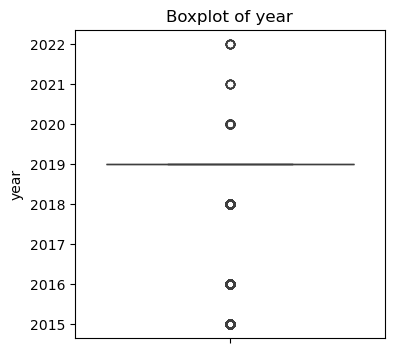

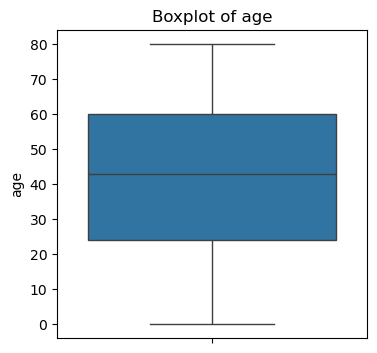

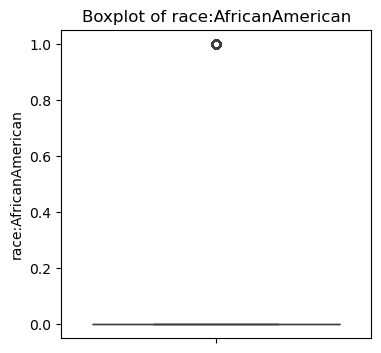

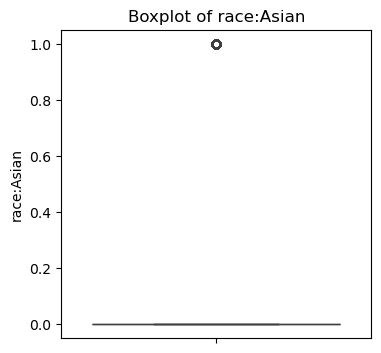

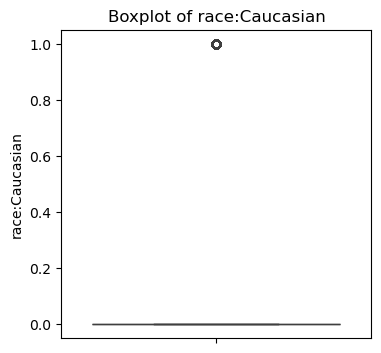

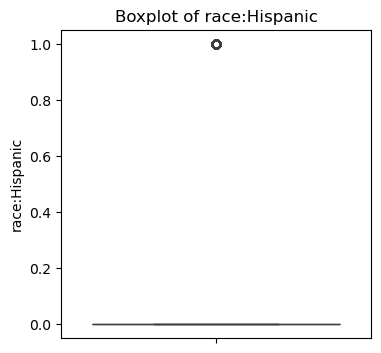

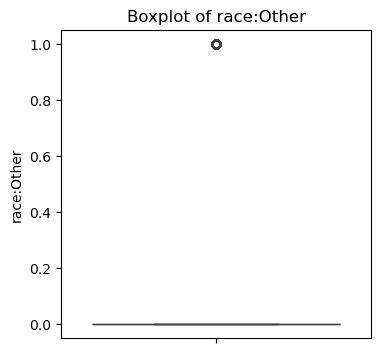

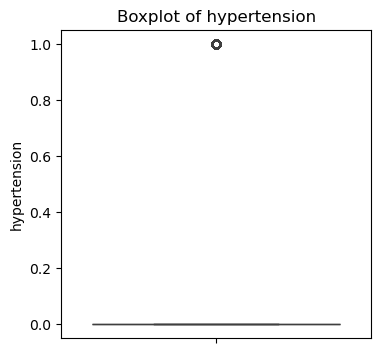

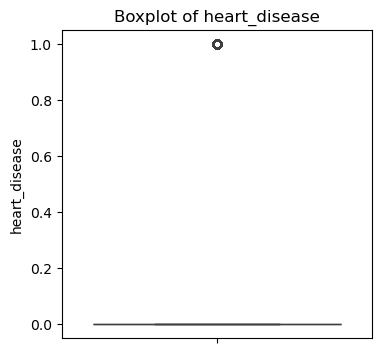

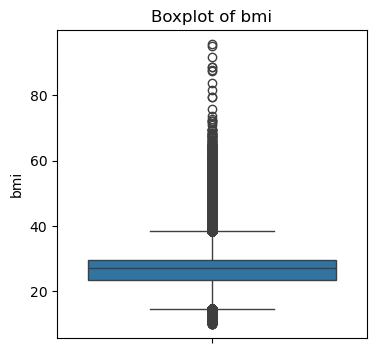

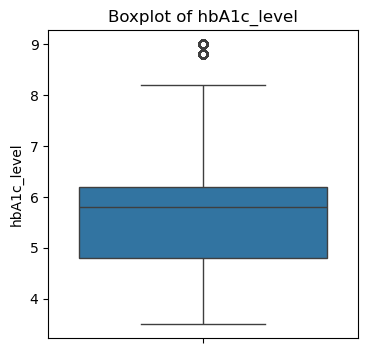

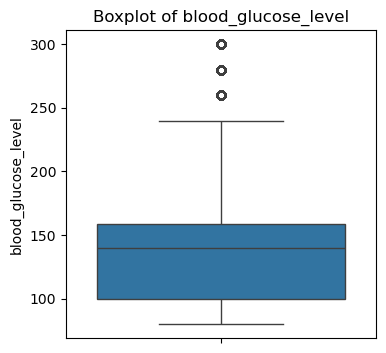

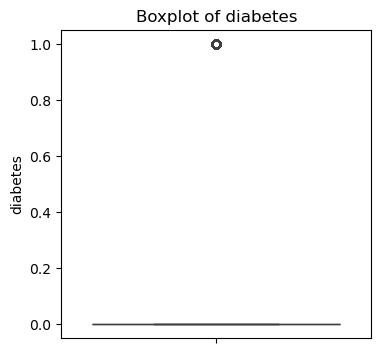

In [12]:
for j in data.select_dtypes(include = ["int64", "float64"]).columns: # We select the quantitative features
  plt.figure(figsize = (4, 4)) # Creation of a new figure
  sns.boxplot(data[j]) # Display of boxplot
  plt.title(f"Boxplot of {j}")
  plt.show()

From what one can see here:
* The *year* feature has some outliers, but this is because more than 75% of patients had their test in 2019 (hence, all the other values are considered as outliers). However, all values are between 2015 and 2022, so none of them is really "extreme". <br>
* The *age* feature does not have any extreme values. <br>
* For the binary features, like *race:Asian*, *race:AfricanAmerican*, *race:Caucasian*, *race:Hispanic*, *hypertension*, *heart_disease* and *diabetes*, "1" is always considered an outlier. This is because the dataset is imbalanced for every one of these features. <br>
* The *BMI* feature contains a lot of outliers, as there are many people that have a BMI greater than 40 (morbid obesity), but also patients that have a BMI less than 15 (severe malnutrition).<br>
* The features concerning the blood glucose level and hbA1c level also have 2-3 outliers, as some points are to be seen after 250 mg/dL for the blood glucose and after 8.5% for the hbA1c.

<br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**D. Duplicated values**

&nbsp;&nbsp;&nbsp;Knowing if our dataset contains duplicated values is also useful and can be done through the *data[data.duplicated()]* command. We can also use the *duplicated.sum()* method to know the exact number of duplicates.

In [13]:
print(f"There are {data.duplicated().sum()} duplicated values that are:")
data[data.duplicated()]

There are 15 duplicated values that are:


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
1479,2019,Female,0,Alabama,0,0,0,1,0,0,0,No Info,16.46,6.0,200,0
2848,2019,Male,40,Alaska,0,0,1,0,0,0,0,No Info,27.32,6.2,85,0
21662,2019,Male,65,Georgia,0,1,0,0,0,0,0,No Info,27.32,4.0,90,0
23313,2019,Female,21,Guam,0,1,0,0,0,0,0,Never,27.32,6.6,155,0
33506,2019,Male,13,Iowa,0,1,0,0,0,0,0,No Info,27.32,4.8,160,0
43401,2019,Male,46,Maryland,0,1,0,0,0,0,0,Never,27.32,6.6,90,0
57881,2019,Female,62,Nebraska,1,0,0,0,0,0,0,No Info,27.32,4.0,126,0
59507,2019,Male,14,Nevada,0,1,0,0,0,0,0,No Info,27.32,6.5,200,0
61867,2019,Female,11,New Hampshire,0,1,0,0,0,0,0,No Info,27.32,6.6,85,0
65311,2019,Female,80,New Mexico,1,0,0,0,0,0,0,No Info,27.32,5.7,159,0


Given the fact that we have 100 000 individuals in this dataset, removing 15 individuals will not have a huge impact on the dataset. Therefore, we can simply delete those lines using *drop_duplicates()* function.

In [14]:
data = data.drop_duplicates()

To make sure that those lines were really deleted, let us use once again the *shape* method to display the number of lines (individuals) and columns (features).

In [15]:
data.shape

(99985, 16)

<br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**E. Visualization (Univariate Analysis)**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Let us now present a univariate analysis of different features from all types (quantitative continuous, quantitative discrete, qualitative nominal, qualitative ordinal, and binary). In this fifth subpart, we will work on:
* *bmi* (quantitative continuous)
* *Age* (quantitative discrete)
* *Location* (qualitative nominal)
* *smoking_history* (qualitative ordinal)
* *heart_disease* (binary)<br><br> We already know that except for the *smoking_history* feature, no feature contained missing values. Therefore, except *smoking_history*, all the univariate analysises will be performed on the 99 985 patients.

<br>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**a. Univariate analysis of bmi (quantitative continuous)**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Let us begin the univariate analysis of *bmi*, a quantitative continuous feature representing the ratio between the patient's weight and his height squared $(\boxed{bmi = \frac{\text{weight}}{\text{height}^2}})$. Those are the BMI categories for adults, according to the article written by the Center for Disease Control and Prevention:
* **Underweight:** BMI $<$ 18.5
* **Healthy Weight:** 18.5 $\leq$ BMI $<$ 25.
* **Overweight:** 25 $\leq$ BMI $<$ 30.
* **Obesity:** BMI $\geq$ 30:<br>
&nbsp;&nbsp;&nbsp; $-$   **First class obesity:** 30 $\leq$ BMI $<$ 35 <br>
&nbsp;&nbsp;&nbsp; $-$   **Second class obesity:** 35 $\leq$ BMI $<$ 40. <br>
&nbsp;&nbsp;&nbsp; $-$   **Third class (morbid obesity):** BMI $>$ 40. <br><br>
&nbsp;&nbsp;&nbsp;Using the *describe()* method allows us to have the principal information about our feature.

In [16]:
data["bmi"].describe()

count    99985.000000
mean        27.320876
std          6.637192
min         10.010000
25%         23.630000
50%         27.320000
75%         29.580000
max         95.690000
Name: bmi, dtype: float64

&nbsp;&nbsp;&nbsp;From what we see here, on average, the patients have a BMI around 27 (overweight). 50% of the individuals' BMI is at least equal to 27.3, while 25% of them have at most a healthy weight (because the first quantile is 23.6).
<br>&nbsp;&nbsp;&nbsp;Moreover, the minimum and maximum values show that there is a patient with severe malnutrition (10.01), while one has extreme obesity (95.69). <br>&nbsp;&nbsp;&nbsp;Finally, the fact that the standard deviation is equal to 6.6 shows that the distribution of BMI among the individuals from the dataset is very scattered, which is normal given the minimum and maximum values.

<br>&nbsp;&nbsp;&nbsp;Because this feature is continuous, we can split the data into classes (5 bins for instance) and then display the histogram in value counts by classes of the feature. To better understand the proportion of each BMI class, we can also present the histogram by frequency and the cumulative distribution function.

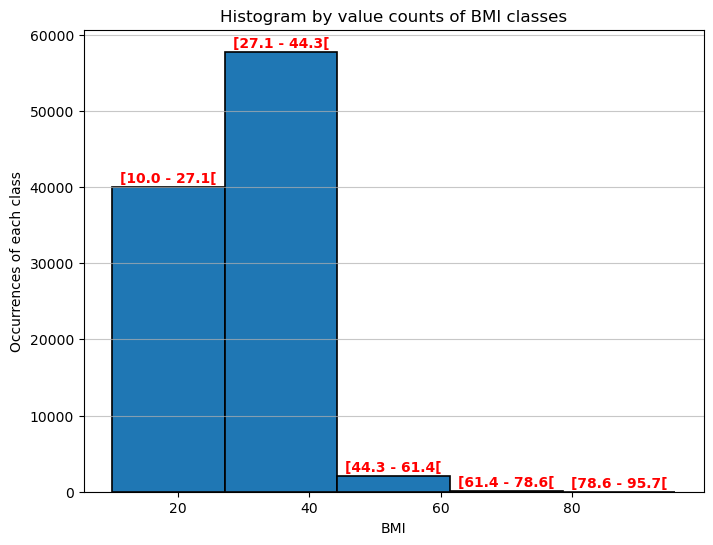

In [17]:
plt.figure(figsize = (8, 6))
valuecounts, bins, _ = plt.hist(data["bmi"], bins = 5, edgecolor = "black", linewidth = 1.2) # We draw the histogram

# We center the text indicating the class at the top of each rectangle of the histogram
labels = [f"[{round(bins[i], 1)} - {round(bins[i+1], 1)}[" for i in range(len(bins) - 1)]
centeredLabels = [(bins[i+1] + bins[i])/2 for i in range(len(bins) - 1)]
for i, j, k in zip(centeredLabels, labels, valuecounts):
  plt.text(i, k + max(valuecounts)/100, j, ha = "center", color = "red", fontweight = "bold")

plt.title("Histogram by value counts of BMI classes")
plt.xlabel("BMI")
plt.ylabel("Occurrences of each class")
plt.grid(axis = 'y', linestyle = '-', alpha = 0.7) # We add a grid, to make the representation easier to understand
plt.show()

<br>

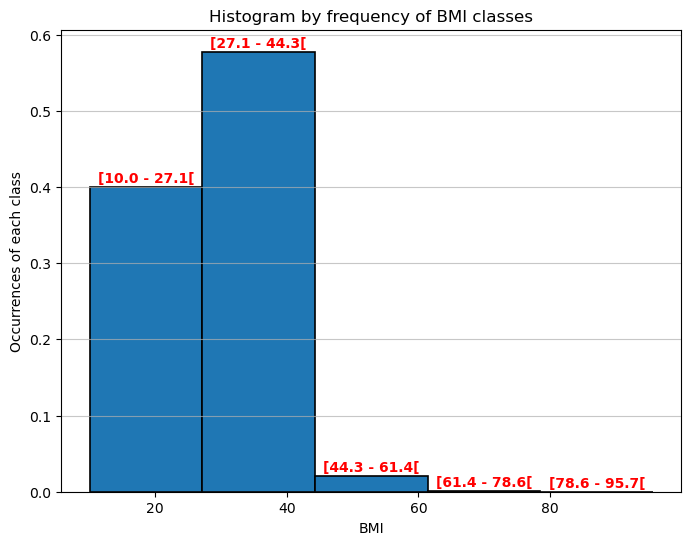

In [18]:
plt.figure(figsize = (8, 6))

# We add the parameter np.ones(len(data))/len(data) to print the histogram in frequency
valuecounts, bins, _ = plt.hist(data["bmi"], bins = 5, edgecolor = "black", linewidth = 1.2, weights = np.ones(len(data)) / len(data)) 

# We center the text indicating the class at the top of each rectangle of the histogram
labels = [f"[{round(bins[i], 1)} - {round(bins[i+1], 1)}[" for i in range(len(bins) - 1)]
centeredLabels = [(bins[i+1] + bins[i])/2 for i in range(len(bins) - 1)]
for i, j, k in zip(centeredLabels, labels, valuecounts):
  plt.text(i, k + max(valuecounts)/100, j, ha = "center", color = "red", fontweight = "bold")

plt.title("Histogram by frequency of BMI classes")
plt.xlabel("BMI")
plt.ylabel("Occurrences of each class")
plt.grid(axis = 'y', linestyle = '-', alpha = 0.7) # We add a grid to make the representation easier to understand
plt.show()

<br>

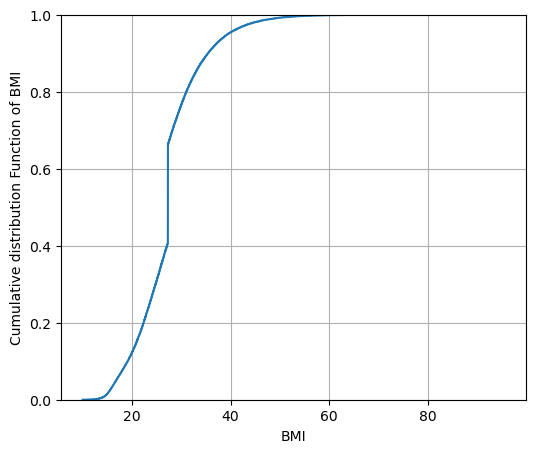

In [19]:
plt.figure(figsize = (6, 5))
sns.ecdfplot(data = data, x = "bmi", linewidth = 1.5)
plt.xlabel('BMI')
plt.ylabel("Cumulative distribution Function of BMI")
plt.grid(True)
plt.show()

These histograms indicate that BMIs' values were separated into 5 classes:
* $ [10, 27.1[$, which represents 40% of patients from the dataset ($\approx$ 40 000 individuals) that are at most overweight (underweight patients, healthy weight patients and overweight patients with a BMI between 25 and 27). <br>
* $ [27.1, 44.3[$, which designates the 55 000 patients ($\approx$ 55% of individuals) in overweight (with a BMI between 27 and 30) or in obesity (from class 1, 2 or 3) <br>
* $ [44.3, 61.4[$, characterizing roughly 3 000 patients ($\approx$ 3% of individuals) that have morbid obesity with a BMI between 44.3 and 61.4. <br>
* $ [61.4, 78.6[$ and $[78.6, 95.7[$ that cumulate less than 1 000 patients ($\approx$ 1% of patients) each and characterize the individuals with extreme obesity (BMI between 61.4 and 78.6 or 78.6 and 95.7).

<br><br>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**b. Univariate analysis of age (quantitative discrete)**

&nbsp;&nbsp;&nbsp;Let us now talk of the "age" feature, representing the age of the patient at the moment of the diabetes test. Once again, we begin with the *describe()* method to display the principal information about the feature.

In [20]:
pd.DataFrame(data["age"].describe())

,age
count,99985.000000
mean,41.876151
std,22.534712
min,0.000000
25%,24.000000
50%,43.000000
75%,60.000000
max,80.000000


&nbsp;&nbsp;&nbsp;This array allows us to understand that the patient's age was approximately 42, while a patient was just a few months old, a few weeks old, or a few days old as proves the minimum value of 0. The fact that the oldest patient was 80 years old justifies the high value of standard deviation (patients from all ages did the test).
<br>&nbsp;&nbsp;&nbsp;Moreover, 25% of the patients ($\approx$ 24 996 patients) were at most 24 years old, while 50% of them were 43 years old and 24 996 patients were older than 60.

In [21]:
print(f"Finally, it is also interesting to remark that the most represented age (the mode) in the dataset is {data["age"].mode().iloc[0]}, "
      "which is also the maximum.")

Finally, it is also interesting to remark that the most represented age (the mode) in the dataset is 80, which is also the maximum.


<br><br>&nbsp;&nbsp;&nbsp;Before looking at the occurrences and frequencies of this feature's values, let us simplify the study by splitting the values into 4 different classes: $[0, 20]$, $[21, 40]$, $[41, 60]$ and $[61, 80]$ using the *pd.cut()* method.

In [22]:
classes = pd.cut(data["age"], bins = [0, 20, 40, 60, 80], labels = ["0-20", "21-40", "41-60", "61-80"], include_lowest = True)
pd.DataFrame({"Occurrencies" : classes.value_counts().sort_index(), "Frequencies" : classes.value_counts(normalize = True).sort_index()})

,Occurrencies,Frequencies
age,,
0-20,20898,0.209011
21-40,25966,0.259699
41-60,29494,0.294984
61-80,23627,0.236305


&nbsp;&nbsp;&nbsp;We understand from this DataFrame that all the classes are balanced, as there are between 20% and 30% of individuals from the dataset for every class. <br>&nbsp;&nbsp;&nbsp;To have a better representation of the distribution of age among the patients from the dataset, we can also display a bar chart and a pie chart using the *plt.pie()* method.

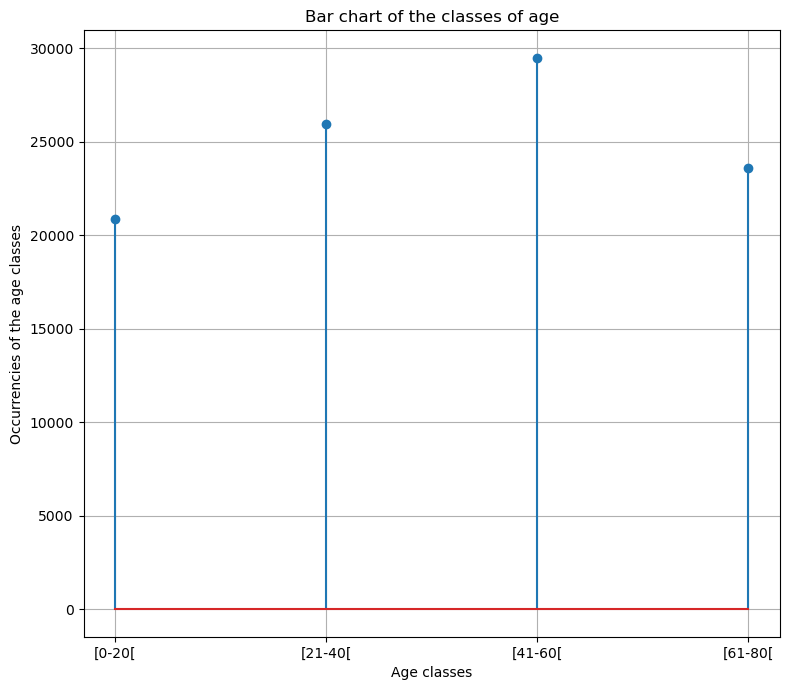

In [23]:
plt.figure(figsize = (8, 7))
plt.stem([f"[{str(i)}[" for i in classes.value_counts().sort_index().index], classes.value_counts().sort_index().values)
plt.title("Bar chart of the classes of age")
plt.xlabel("Age classes")
plt.ylabel("Occurrencies of the age classes")
plt.grid(True)
plt.tight_layout()
plt.show()

<br>

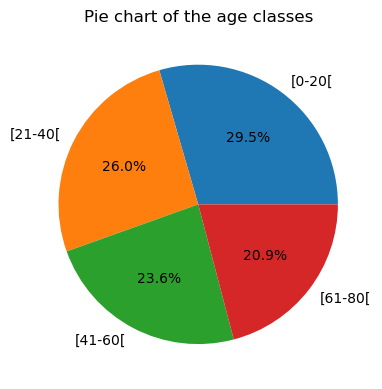

In [24]:
plt.figure(figsize = (4, 4))
plt.pie(classes.value_counts(), labels = [f"[{str(i)}[" for i in classes.value_counts().sort_index().index], autopct = '%1.1f%%')
plt.title("Pie chart of the age classes")
plt.tight_layout()
plt.show()

<br><br>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**c. Univariate analysis of Location (qualitative nominale)**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Let us continue by presenting a univariate analysis of the *Location* feature representing the place where the patient lives (district or state for instance). We will begin the univariate analysis study of this qualitative nominal feature with the distribution (frequencies and occurrences) to see if some regions are overrepresented or underrepresented. To simplify the understanding and the comparison, we will put every result in a DataFrame.

In [25]:
pd.DataFrame({"Occurrences": data["location"].value_counts(), "Frequencies": data["location"].value_counts(normalize = True)})

,Occurrences,Frequencies
location,,
Hawaii,2038,0.020383
Kentucky,2038,0.020383
Arkansas,2037,0.020373
Florida,2037,0.020373
Iowa,2037,0.020373
Nebraska,2037,0.020373
Minnesota,2037,0.020373
New Jersey,2037,0.020373
Massachusetts,2036,0.020363


&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;From what one can understand, it seems that the repartition of the provenance of the patients is really homogeneous for all the patients. Given the perfect scores of the dataset, it seems that the dataset has been cleaned before, as we saw in the introduction. Anyway, we will continue by displaying the countplot of *Location* to have a visual representation of this distribution.

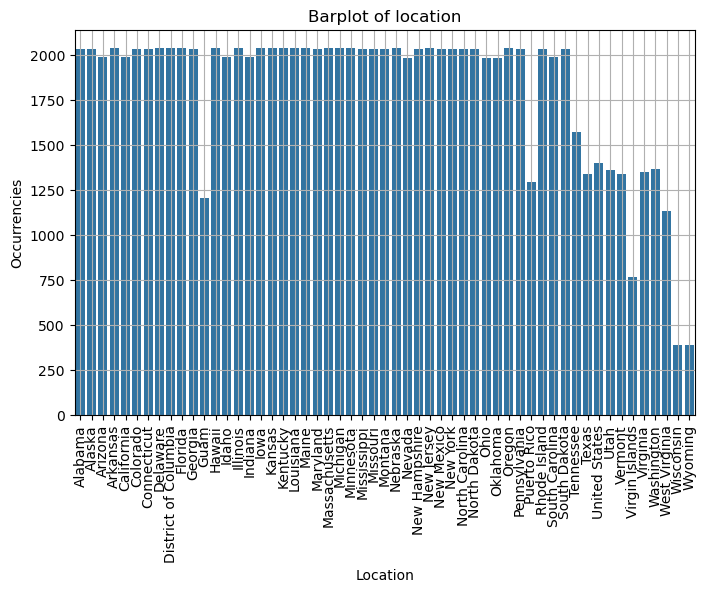

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(x = "location", data = data)
plt.title("Barplot of location")
plt.xlabel("Location")
plt.ylabel("Occurrencies")
plt.xticks(rotation = 90)
plt.grid(True)
plt.show()

&nbsp;&nbsp;&nbsp;This graphic confirms the homogeneity of the distribution, as a great majority of the values taken have approximately 2000 occurrences. From those graphics, one can also understand that every patient in this dataset comes from the United States of America. Therefore, the study of our model is based on the USA only (and not the world, as we could have thought).

<br><br>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**d. Univariate analysis of smoking_history (qualitative ordinale)**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Let us now continue with the feature *smoking_history*, indicating the patient's smoking frequency, with this hierarchy:<br>
* "Never" (level 0)
* "Not Current" (level 1)
* "Former" (level 2)
* "Ever" (level 3)
* "Current" (level 4). <br>Because we have "No Info", as we saw before, we will temporarily (only for this sub subpart) create a new feature called "mapped_smoking". It will attribute the level of the hierarchy instead of the words (for instance, *mapping_history* will take the value 0 if the frequency is "never"). It will allow us to consider *mapped_smoking* like a quantitative discrete feature, and therefore computing more indicators. <br>
However, because we do not have information on the smoking history of 35816 patients, the numbers that we will treat in this part will only be on the 64180 remaining patients.

In [27]:
data["smoking_mapped"] = data["smoking_history"].map({"Never": 0, "Not Current": 1, "Former": 2, "Ever": 3, "Current": 4})

<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;We can now display the principal information of the *smoking_mapped*.

In [28]:
pd.DataFrame(data["smoking_mapped"].describe())

,smoking_mapped
count,64180.000000
mean,1.157791
std,1.489745
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,4.000000


&nbsp;&nbsp;&nbsp;From what one can see, on average, the patients are either not current smokers or former ones. However, the fact that the standard deviation is so high ($\approx$ 1.5) given the few numbers of levels proves that we find all types of smokers in the dataset. The quantiles show us that more than 50% of the remaining patients have never smoked.

<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;To have a better representation, let us display the pie chart and the cumulative distribution function of *smoking_mapped*.

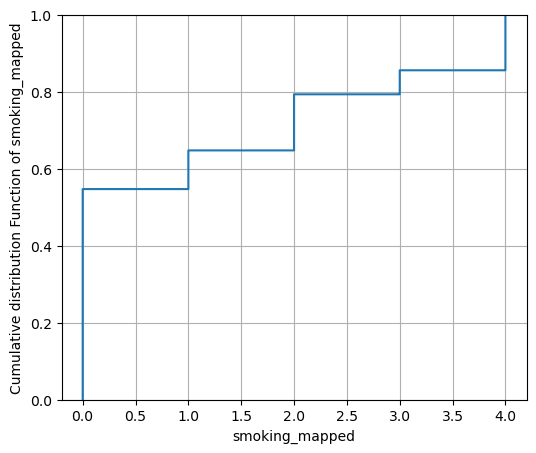

In [29]:
plt.figure(figsize = (6, 5))
sns.ecdfplot(data = data, x = "smoking_mapped", linewidth = 1.5)
plt.xlabel('smoking_mapped')
plt.ylabel("Cumulative distribution Function of smoking_mapped")
plt.grid(True)
plt.show()

<br>

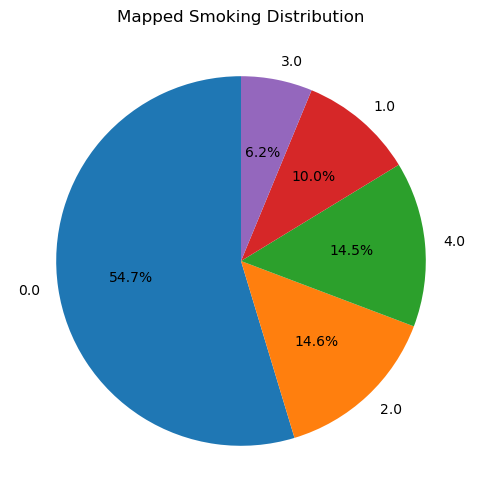

In [30]:
plt.figure(figsize = (6,6))
data["smoking_mapped"].value_counts().plot.pie(autopct = "%1.1f%%", startangle = 90, ylabel = "")
plt.title("Mapped Smoking Distribution")
plt.show()

&nbsp;&nbsp;&nbsp;We understand that a strong imbalance exists across categories. Among the recorded categories, "Never" smokers form the biggest group, followed by "Former" and "Current" smokers, indicating that a smaller portion of the population is active smokers. The categories "Not Current" and "Ever" represent only a minor share of the dataset. <br>However, once again, the presence of so many "No Info" may limit the informative level of this feature during model training. <br><br>&nbsp;&nbsp;&nbsp;Let us now remove *smoking_mapped*.

In [31]:
data = data.drop(columns = ["smoking_mapped"])

<br><br>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**e. Univariate analysis of heart_disease (binary)**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Finally, let us deal with the feature *heart_disease*, which is binary. It is first useful to see what the distribution is.

In [32]:
data["heart_disease"].value_counts()

heart_disease
0    96043
1     3942
Name: count, dtype: int64

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;From that, we understand that a very large majority of people do not have heart disease in this dataset. To have a better representation of the reality, we can display the barplot with the frequencies.

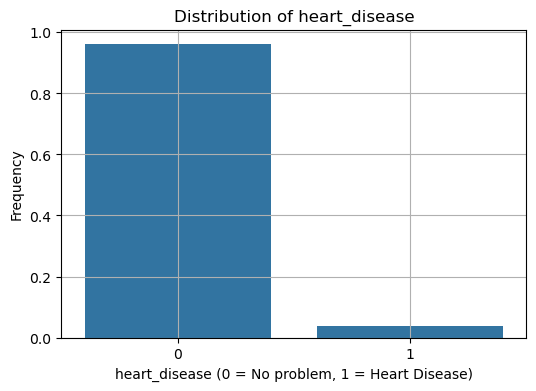

In [33]:
plt.figure(figsize = (6,4))
sns.barplot(x = data["heart_disease"].value_counts(normalize = True).index, y = data["heart_disease"].value_counts(normalize = True).values)
plt.title("Distribution of heart_disease")
plt.xlabel("heart_disease (0 = No problem, 1 = Heart Disease)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

<br><br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**F. Data balance**

&nbsp;&nbsp;&nbsp;Let us now continue our analysis and preprocessing of the dataset by observing the balance of the feature "diabetes". This process will help us know which models and pipelines will be used later.
<br>&nbsp;&nbsp;&nbsp;First, let us use once again the *value_counts()* method to print the number of occurrences of both classes (0 and 1) for the target feature: "diabetes".
<br>&nbsp;&nbsp;&nbsp;We can also use *min* and *max* functions to calculate the ratio between the minority class and the majority one.  

In [34]:
print(data["diabetes"].value_counts())
ratio = data["diabetes"].value_counts().max() / data["diabetes"].value_counts().min()
print(f"Imbalance ratio ≈ 1:{ratio:.2f}")

diabetes
0    91485
1     8500
Name: count, dtype: int64
Imbalance ratio ≈ 1:10.76


&nbsp;&nbsp;&nbsp;From what one can see here, the majoritarian class is the 0 (representing the patients without diabetes), while the minority class is the 1 (diabetic patients).<br>
The fact that there are 10.76 times more patients without diabetes than patients with diabetes proves that this feature is moderately imbalanced. To counter this imbalance, some models like RandomOverSampling or SMOTE will be used later.

<br><br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**G. Correlation analysis and encoding**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this part, we will study the correlation between the different features and use encoding to split qualitative features into dummy ones (quantitative binary).
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Let us first display the correlation matrix to see which features are independent (correlation close to 0) from the others and which ones directly depend on one another (correlation close to $\pm1$).

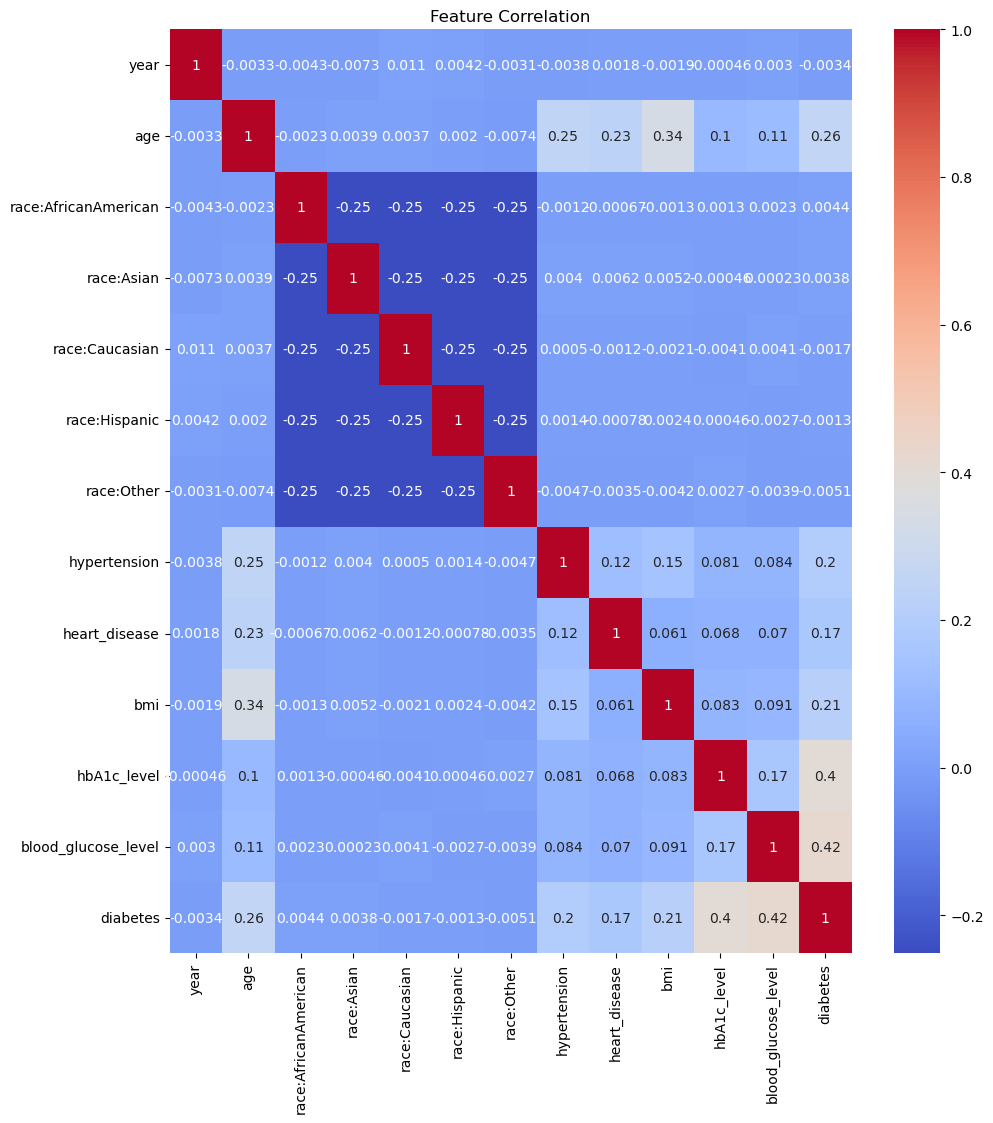

In [35]:
plt.figure(figsize = (11, 12))
sns.heatmap(data.corr(numeric_only = True), annot = True, cmap = 'coolwarm') # We keep only quantitative features and print the correlation matrix
plt.title("Feature Correlation")
plt.show()

If we look at the last line of this matrix, we can see that the most correlated features to *diabetes* are:
* *blood_glucose_level* (correlation of 0.42)
* *hbA1c_level* (correlation of 0.4)
* *age* (correlation of 0.26)
However, the relationship between those variables and diabetes is slight (between 0.2 and 0.5) and qualitative features do not appear in the matrix.
<br><br>To resolve this problem, let us transform the qualitative features into quantitative binary features using *pd.get_dummies* function. To make sure that the new features will take 0/1 values instead of "True"/"False", we can add the parameter: *dtype = int*.

In [36]:
df_encoded = pd.get_dummies(data, columns = data.select_dtypes(include = "object").columns, drop_first = True, dtype = int)
df_encoded.head()

,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,...,location_Virginia,location_Washington,location_West Virginia,location_Wisconsin,location_Wyoming,smoking_history_Ever,smoking_history_Former,smoking_history_Never,smoking_history_No Info,smoking_history_Not Current
0,2020,32,0,0,0,0,1,0,0,27.32,...,0,0,0,0,0,0,0,1,0,0
1,2015,29,0,1,0,0,0,0,0,19.95,...,0,0,0,0,0,0,0,1,0,0
2,2015,18,0,0,0,0,1,0,0,23.76,...,0,0,0,0,0,0,0,1,0,0
3,2015,41,0,0,1,0,0,0,0,27.32,...,0,0,0,0,0,0,0,1,0,0
4,2016,52,1,0,0,0,0,0,0,23.75,...,0,0,0,0,0,0,0,1,0,0


<br>&nbsp;&nbsp;&nbsp;Let us now see the new number of columns (features) and lines (individuals).

In [37]:
df_encoded.shape

(99985, 74)

&nbsp;&nbsp;&nbsp;As one can see, approximately 60 new features appeared, and we now have 99 985 individuals and 74 features.
<br><br>&nbsp;&nbsp;&nbsp;Because all the features are now quantitative, we can once again display the correlation matrix of the explicative features with diabetes. To enhance the visibility of the matrix (because we now have 74 features), we will apply a filter. Only the line with diabetes and the features sharing an absolute correlation of more than 0.25 with diabetes will be kept.

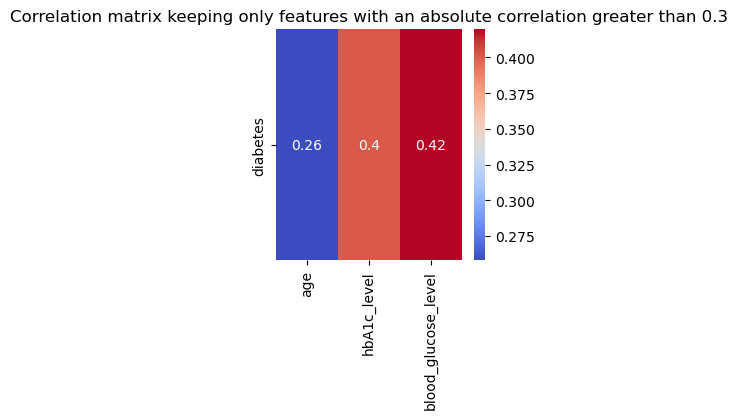

In [38]:
matrix = df_encoded.corr(numeric_only = True)
matrix_temp = matrix["diabetes"].drop("diabetes") # We delete the cell showing the relationship between diabetes and itself (useless)
matrix_filtered = matrix_temp[abs(matrix_temp) > 0.25] # Filter
plt.figure(figsize = (3, 3))
sns.heatmap(matrix_filtered.to_frame().T, annot = True, cmap = 'coolwarm') # We convert the matrix into a DataFrame and print its transpose 
                                                                           # (better visibility).
plt.title("Correlation matrix keeping only features with an absolute correlation greater than 0.3")
plt.show()

&nbsp;&nbsp;&nbsp;From this final correlation matrix, we understand that the variables the most correlated to "diabetes" are the blood glucose level (correlation of 0.42), then the hbA1c_level (correlation of 0.4), and finally the age (0.26). However, once again, those correlations with diabetes remain slight (for hba1c_level and blood_glucose_level) or even weak (for age). <br>
&nbsp;&nbsp;&nbsp;One can also see that considering or not considering the qualitative features is the same in terms of correlation (they did not change an inch).

<br><br>

# **2. Train_test_split and implementation of algorithms and pipelines**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;As we saw in the first part, the dataset's feature target is "diabetes", while the other features are explicative ones. This is the reason why the feature "diabetes" will be called *y* while the others will be gathered in a variable called *X*.<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Then, we will use the *train_test_split* function with a *test_size* of 0.3 to split our dataset into a training set (70%) to fit the model and a test set (30%) to test it. The parameter *stratify = y* to keep the same class proportions during the separation, and *random_state = 42* to ensure the reproducibility of the split will be added.

In [39]:
X = df_encoded.drop(columns = ['diabetes']).copy()
y = df_encoded['diabetes'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

<br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**A. Baseline models**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Now, we can develop some models to predict if a patient has diabetes or not. For the moment, we will not consider the imbalance of *diabetes*. To evaluate the models, a function called "model_evaluation" will be defined, whose steps are:<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**a)** Predict the *diabetes* feature for the test part (using the model that has been trained earlier).<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**b)** Train the model based on *X_train* and *y_train* using the *fit()* function.<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**c)** Apply the trained model to binary classify the target feature (*diabetes*) using this time *X_test*.<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**d)** Predict the probabilities of X_test.<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**e)** Display the different metrics to properly evaluate the models:<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$-$ **AUC-ROC** (Area Under the Receiver Operating Characteristic curve): This metric indicates if the model is good at separating the two classes (the closer to 1 the AUC, the better the separation). The ROC graphic displays the proportion of True Positive (also called "TP", which is the number of diabetic patients that were classified as diabetics) with relation to the proportion of False Positive ("FP", the number of non-diabetic patients that were classified as diabetics) for several thresholds.<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$-$ **AUC-PR** (Area Under the Precision-Recall curve): The Precision-Recall graphic displays the precision in relation to the recall metric. The closer to 1 the AUC-PR, the better the detection of TP while limiting the FP.<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$-$ **Precision**: By definition, $\boxed{Precision = \frac{TP}{TP + FP}}$. In an easier way, it represents the proportion of predictions that were truly positive. It answers the question: when a patient is told to be diabetic, does it truly have one?. <br><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$-$ **Recall**: By definition, $\boxed{Recall = \frac{TP}{TP + FN}}$, with FN ("False Negative") the number of people classified as healthy, while they truly have diabetes in real life (the worst case that can happen in our dataset). It corresponds to the proportion of TP among all the positive. It answers the question: is the model efficient for detecting diabetic patients?.<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$-$ **$F_1$-score**: By definition, $\boxed{F_1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}}$. Its purpose is to harmonize the precision and the recall, and to keep the TN and FP under control.<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**f)** Print the confusion matrix to have the number of TP, TN, FP and FN, with TN ("True Negative") the number of non-diabetic patients classified as such.<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**g)** Compute the Custom Cost (it will also be called "CC" in this notebook). We decided that: $Custom Cost = 10\times FN + FP$. Indeed, attributing a weight of 10 for every FN proves that the FP are the worst case of all and need to be avoided as much as possible. Because the number of FN is also really important, a weight of 1 was also attributed to every FP. Therefore, the CC gives an idea of the validity of the model. Even if it will be determinant during the choice of the best models, we will also need to look at all the other metrics to avoid overfitting (learning too much from the training dataset while badly performing on the test data). Indeed, sometimes, a model can have a low Custom Cost (high recall, high AUC-PR, and/or high $F_1$), but also a low accuracy for instance, which makes a model go down in the ranking of the best models. <br><br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In all the notebook, when we talk of the metrics (except if it will be precised of course), it will be for the minority class by default. Indeed, because of the imbalance of *diabetes*, the metrics for the majoritarian class are always high. Therefore, talking about them does not add any additional information: it is the consideration of the minority class that really matters.

In [40]:
def model_evaluation(model, X_train, y_train, X_test, y_test, label):
    print(f"\n---- {label} Model ----")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    FP_Rate, TP_Rate, _ = roc_curve(y_test, y_proba)
    _, FP, FN, _ = confusion_matrix(y_test, y_pred).ravel()
    print(f"{classification_report(y_test, y_pred)}\n\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}\n\nAUC-PR = {auc(recall, precision):.2f}, "
          f"AUC-ROC = {auc(FP_Rate, TP_Rate):.2f}\n\nCustom Cost = {10 * FN + FP}\n\n")

<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this second part of the project, we will consider several classification models such as LogisticRegression, DecisionTree, RandomForest, XGBoost, and GradientBoost. A dictionary called *first_models* containing all those will be defined. In this part, we will use those models without considering the imbalance of *diabetes*, nor a dimensionality reduction, nor GridSearch, nor Stacking, Voting, and Bagging.

* ***Logistic Regression ("LR")*** is a linear model that estimates probabilities using a logistic function $(\boxed{\sigma(x) = \frac{1}{1 + e^{-(w^Tx + b)}}})$. If $\sigma$ is greater than 0.5 for a certain input, the LR classifies the individual as diabetic and healthy otherwise. It takes two hyperparameters: *max_iter = 2000*, which ensures an enough number of iterations to make the problem converge and *random_state = 42*, which ensures the reproducibility of results. It was chosen because it is easy to train and to understand, even if it can't understand non-linear relationships between the target and the explicative features.

* ***Decision Tree ("DT")***, as for it, is a non-linear model that splits data into branches based on feature values. It is better than LogisticRegression because it also captures relationships that are not linear. In addition to having a random state of 42, we decided to create new nodes in the tree if it was composed of more than 55 individuals (*min_samples_split = 55*). This hyperparameter avoids too much division inside the tree, and therefore adds some stability to the model. Because we have a large number of patients, we allow the tree to have a maximal depth of 10 (*max_depth = 10*). Increasing this depth could make the model overfit (learning too much from the training dataset and performing worse with the test dataset). Finally, the parameter *min_samples_leaf = 20* has been added to indicate to the model to create another leaf if more than 20 individuals respect all the conditions of the corresponding leaf. This parameter also prevents the overfitting by not focusing too much on the "details".

* ***Random Forest ("RF")*** is an ensemble of decision trees that improve accuracy and reduce overfitting. To do that, it uses several independent Decision Trees constructed on a subpart of the dataset. The DecisionTree that is the most convenient (the most votes from all the trees) is finally selected. Once more, for this model, we used the hyperparameter *random_state = 42*. Because of *Random Forest*'s ability to handle the dataset's noise and the imbalance, we decided to use it for this binary classification problem.

* ***Gradient Boosting ("GB" or "gradient")*** is a sequential ensembles model containing several Decision Trees. At each iteration, a new tree is defined and learns from mistakes of the previous ones by minimizing the gradient of the loss function. Therefore, because it is also perfect for the detection of non-linear relationships, it is more powerful than the other models. However, sometimes, the easiest models are the best ones, this is the reason why we will give every model its chance to be tested. For the hyperparameters, in addition to the random state, 300 estimators will be used to enhance the performance, but with a lower learning rate (0.05 here) to prevent overfitting. The overfitting on this large dataset ($\approx$ 100k individuals) will also be avoided using a minimal sample split of 20 and minimum sample leaf of 10.

* ***XGBoost***, finally, is also an ensembles model enhancing the GB by adding penalties regularization (L1/L2). Also using parallelization, it is, just like the gradient, one of the most performant models that exist for classification. This is the reason why we indicated the logloss as the metric to improve. However, just like the GradientBoosting, this model performance comes with a high memory requirement, and a greater time complexity. About the other hyperparameters, a learning rate of 0.1 has been chosen because it is not too high, but not too low either for an XGB. The fact of tolerating a maximal depth of 5, instead of 3, like for the Gradient, allows the model to capture more patterns (but can also increase the overfitting of course).


Even if those are the hyperparameters chosen for the first models, according to the results (we will apply the method *model_evaluation* on all the models from *first_models*), they will be adapted to avoid overfitting while maximizing their performance. 

In [41]:
first_models = { "Logistic Regression": LogisticRegression(max_iter = 2000, random_state = 42),
  "Decision Tree": DecisionTreeClassifier(random_state = 42, max_depth = 10, min_samples_split = 55, min_samples_leaf = 20),
  "Random Forest": RandomForestClassifier(random_state = 42),
  "Gradient Boosting": GradientBoostingClassifier(random_state = 42, n_estimators = 300, learning_rate = 0.05, max_depth = 3, min_samples_split = 20, 
                                                  min_samples_leaf = 10),

  "XGB": XGBClassifier(random_state = 42, eval_metric = "logloss", learning_rate = 0.1, max_depth = 5)}

for name, model in first_models.items():
    model_evaluation(model, X_train, y_train, X_test, y_test, name)


---- Logistic Regression Model ----
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     27446
           1       0.86      0.63      0.73      2550

    accuracy                           0.96     29996
   macro avg       0.91      0.81      0.85     29996
weighted avg       0.96      0.96      0.96     29996


Confusion Matrix:
[[27190   256]
 [  943  1607]]

AUC-PR = 0.81, AUC-ROC = 0.96

Custom Cost = 9686



---- Decision Tree Model ----
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27446
           1       0.97      0.68      0.80      2550

    accuracy                           0.97     29996
   macro avg       0.97      0.84      0.89     29996
weighted avg       0.97      0.97      0.97     29996


Confusion Matrix:
[[27387    59]
 [  815  1735]]

AUC-PR = 0.87, AUC-ROC = 0.97

Custom Cost = 8209



---- Random Forest Model ----
              precision    recall  f1-sco

This is what we understand from all this:
* **For the LogisticRegression ("LR"):**
The results for the majoritarian class are excellent, as prove the scores between 0.97 and 0.99 for the precision, recall, and $F_1$ score. This high recall shows us that the model knows almost always when a patient is not diabetic (class 0). However, when we look at the recall for the minority class (0.63) and the number of FN in the confusion matrix (943), we understand this model is not valid as it favors too much the majoritarian class. Indeed, 943 diabetic patients in real life have been classified as non-diabetic, which is a lot. This directly impacts the Custom Cost that is equal to 9686 (way too high). Using SMOTE with the parameter *class_weight = "balanced"* will be used to improve the reliability of this model in the second subpart.<br><br>

* **For DecisionTree ("DT"):** For this model, the results for the minority class (diabetic patients) are slightly better for the recall (0.68) than for the Logitic Regression, meaning that the DT recognizes more diabetic patients. Because the AUC-PR (0.87 for DT against 0.81 for LR) and AUC-ROC (0.97 for DT) are higher for the DecisionTree than for the LogisticRegression, the DT is more reliable in terms of probability. Moreover, the number of FP is lower than for the LogisticRegression (59 against 256), which means that 59 individuals have falsely been classified as diabetic, which is few compared to the LogisticRegression, but still non-negligible. However, the model still classifies 815 diabetic patients as non-diabetics, which is really high and leads to a high Custom Cost of 8209. Therefore, this model cannot be trusted either.<br><br>

* **For RandomForest ("RF"):** At first glance, the RandomForest seems to be effective when classifying the patients, especially the diabetic ones. Indeed, for the minority class, the model has a precision of 1 and has 8 FP, which means that every diabetic patient was predicted as diabetic and only 8 non-diabetics were diagnosed as diabetic. The fact that the AUC-PR (0.85) and AUC-ROC (0.96) are really high proves that despite the imbalance, the model is efficient in its prediction. However, there are still 846 diabetic patients that were identified as non-diabetic (FN = 846), which is a lot and leads to a high Custom Cost of 8468. SMOTE will be used with the parameter class_weight = 'balanced_subsample' to help improve the model's score. <br><br>

* **For GradientBoosting:** Just as RandomForest, the GradientBoosting model performs extremely well on the majoritarian class (precision = 0.97 and recall = 1.00). For the minority class (diabetic patients), the model reaches a recall of 0.68 and an F1 score of 0.81, which is one of the best results among all baseline models. Moreover, the AUC-PR (0.88) and AUC-ROC (0.98) are the highest obtained so far, proving that GradientBoosting is very reliable in terms of probability estimation and discrimination between the two classes. However, despite these strong results, the model still misclassifies 805 diabetic patients as non-diabetic (FN = 805), which remains significant and conducts to a Custom Cost of 8088. Therefore, even if this model is one of the most promising, oversampling or undersampling techniques will perhaps help further improve its ability to detect diabetic patients.<br><br>

* **For XGBoost ("XGB"):** The XGB model behaves very similarly to the GradientBoosting model, showing excellent performance on the majoritarian class with a precision of 0.97 and a recall of 1.00. For the minority class (diabetic patients), it obtains a recall of 0.68 and an F1 score of 0.8, placing it among the best models of the baseline. In addition, the AUC-PR (0.88) and AUC-ROC (0.98) metrics confirm that XGBoost is highly reliable in terms of probability estimation and its capacity to distinguish diabetic from non-diabetic patients despite the significant imbalance. However, the confusion matrix shows that 819 diabetic patients were classified as non-diabetic (FN = 819), which remains high even though it is slightly lower than RandomForest’s FN value. Therefore, XGB stands, together with GradientBoosting, as the strongest baseline models before applying any balancing technique because they also have ones of the lowest CC.

<br><br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**B. Creation of models considering the imbalance of *diabetes***

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In the previous part, we did not consider the imbalance of *diabetes* for the creation of the baseline models. Therefore, the models generally tended to favor too much the majoritarian class (non-diabetic patients), which decreased the performance of the models. Using the methods below, we will now try to enhance those results by balancing the dataset:<br>
* **RandomOverSampling (ROS):** This process uses the *RandomOverSampler()* command to replicate existing samples from the minority class (the diabetic patients). At the end, both classes are equally represented in the distribution. Usually, this tool is used to enhance the recall metric, but can sometimes decrease the overall performance. <br>

* **RandomUnderSampling (RUS):** This process, as for it, uses the *RandomUnderSampler()* command to reduce the number of samples from the majoritarian class (the "healthy" patients). Just as the RandomOverSampling, at the end, both classes are equally represented, and RandomUnderSampling's goal is also to enhance the recall. However, sometimes, it can impact the global performance of the model.<br>

* **SMOTE (Synthetic Minority Oversampling Technique):** Instead of duplicating existing samples, this technique produces synthetic observations coming from the diabetic class to enhance all the metrics (ROC-AUC, ROC-PR, recall...). It also aims at preventing the possible overfitting of the two precedent methods.

<br><br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Let us first define another function called *model_evaluation_imbalance()* to compare the models. However, for the *RandomOverSampling*, *RandomUnderSampling* and *SMOTE*, fitting the model must be done after the resampling. Therefore, we will simply take the previous function (*evaluate_model()*), but without the train_test_split and the fitting at the beginning.

In [42]:
def model_evaluation_imbalance(model, X_test, y_test, label):
  print(f"\n---- {label} Model ----")
  y_pred = model.predict(X_test)
  y_proba = model.predict_proba(X_test)[:, 1]

  precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
  FP_Rate, TP_Rate, _ = roc_curve(y_test, y_proba)
  _, FP, FN, _ = confusion_matrix(y_test, y_pred).ravel()

  print(f"{classification_report(y_test, y_pred, zero_division = 0)}\n\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}\n\n"
        f"AUC-PR = {auc(recall, precision):.2f}, AUC-ROC = {auc(FP_Rate, TP_Rate):.2f}\n\nCustom Cost = {10 * FN + FP}\n\n")

<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Now that this method has been created, we can *train_test_split* the dataset. We will take exactly the same models as during the baseline. However, this time, they will be split into two dictionaries. The first dictionary will see the hyperparameter *class_weight = "balanced"* added to all its models, while the second one will not change a single thing. Indeed, for the GradientBoosting and XGB, adding this hyperparameter will decrease the performance of the results, while it usually has the opposite effect for LogisticRegression, DecisionTree and RandomForest.
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;To ensure the convergence of the *LogisticRegression* model, we changed the maximum number of iterations to 5,000.

In [43]:
models_balanced = {"Logistic Regression": LogisticRegression(max_iter = 10000, random_state = 42, class_weight = "balanced"),
  "Decision Tree": DecisionTreeClassifier(random_state = 42, max_depth = 10, min_samples_split = 55, min_samples_leaf = 20, class_weight = "balanced"),
  "Random Forest": RandomForestClassifier(random_state = 42, class_weight = "balanced")}


models_not_balanced = { "Gradient Boosting": GradientBoostingClassifier(random_state = 42, n_estimators = 300, learning_rate = 0.05, max_depth = 3, 
                                                                        min_samples_split = 20, min_samples_leaf = 10),

  "XGB": XGBClassifier(n_estimators = 210, random_state = 42, eval_metric = "logloss", learning_rate = 0.1, max_depth = 5)}

<br>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**a. RandomOverSampling**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;We can now begin the creation of the models using *RandomOverSampling*. The first thing to do is to define a *random_over* variable that will resample *X_train* and *y_train* using RandomOverSampler. Just as before, the hyperparameter *random_state = 42* makes sure of the reproducibility of the results. Compared to the baseline, this time, all the models will need to be fit before calling the method *model_evaluation_imbalance*.

In [44]:
random_over = RandomOverSampler(random_state = 42)
X_random_over, y_random_over = random_over.fit_resample(X_train, y_train)
print("Distribution of the resampled class:", Counter(y_random_over))

for name, model in models_balanced.items():
    model.fit(X_random_over, y_random_over)
    model_evaluation_imbalance(model, X_test, y_test, f"RandomOverSampling for weighted {name}")

for name, model in models_not_balanced.items():
    model.fit(X_random_over, y_random_over)
    model_evaluation_imbalance(model, X_test, y_test, f"RandomOverSampling for {name} (without class weight)")

Distribution of the resampled class: Counter({0: 64039, 1: 64039})

---- RandomOverSampling for weighted Logistic Regression Model ----
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     27446
           1       0.41      0.87      0.56      2550

    accuracy                           0.88     29996
   macro avg       0.70      0.88      0.75     29996
weighted avg       0.94      0.88      0.90     29996


Confusion Matrix:
[[24289  3157]
 [  327  2223]]

AUC-PR = 0.81, AUC-ROC = 0.96

Custom Cost = 6427



---- RandomOverSampling for weighted Decision Tree Model ----
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     27446
           1       0.44      0.90      0.59      2550

    accuracy                           0.89     29996
   macro avg       0.71      0.90      0.76     29996
weighted avg       0.94      0.89      0.91     29996


Confusion Matrix:
[[24523  2923]
 [  258  2

&nbsp;&nbsp;&nbsp;For all models except the RandomForest, applying the RandomOverSampling increased the recall, but really deteriorated the other metrics' results. <br>
&nbsp;&nbsp;&nbsp;For the RandomForest model, the recall (0.7 instead of 0.67) and the AUC-ROC (0.97 instead of 0.96) are better than the ones for the baseline RandomForest (more diabetes detected). The $F_1$ and the AUC-PR are constant, while the number of FP was multiplied by almost 23. However, when we look at its CC, we see that it is largely better than the baseline RF's (7763 instead of 8468). <br>
&nbsp;&nbsp;&nbsp;About the GradientBoosting and XGB, the situation is different from the others. Indeed, we observe an increase in the recall (0.91 for both models instead of 0.68 for both models also), and a consequent amelioration of the CC (both of them were almost divided by 2 thanks to the reduction of the number of FN). However, for the Random OverSampling, the $F_1$ score decreases a lot ($-0.2$ on average for both models), while the number of FP exploded (2458 v 20 for the XGB, and 2627 v 38 for the Gradient). <br>
&nbsp;&nbsp;&nbsp;Therefore, because on average and by considering all the parameters, the RandomOverSampling deteriorated the results, for the moment, the best models are still the GradientBoosting and XGBoost from the baseline. 

<br><br>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**b. RandomUnderSampling**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Let us now continue with RandomUnderSampling. This time also, a variable called *random_under* will allow us to apply the corresponding technique (here, the RUS) on the model with a random state hyperparameter of 42. For all iterations, the fitting of the models will be performed before calling the method *model_evaluation_imbalance*. 

In [45]:
random_under = RandomUnderSampler(random_state = 42)
X_random_under, y_random_under = random_under.fit_resample(X_train, y_train)
print("Distribution of the resampled class:", Counter(y_random_under))

for name, model in models_balanced.items():
    model.fit(X_random_under, y_random_under)
    model_evaluation_imbalance(model, X_test, y_test, f"RandomUnderSampling for weighted {name}")

for name, model in models_not_balanced.items():
    model.fit(X_random_under, y_random_under)
    model_evaluation_imbalance(model, X_test, y_test, f"RandomUnderSampling for {name} (without class weight)")

Distribution of the resampled class: Counter({0: 5950, 1: 5950})

---- RandomUnderSampling for weighted Logistic Regression Model ----
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     27446
           1       0.41      0.87      0.56      2550

    accuracy                           0.88     29996
   macro avg       0.70      0.88      0.75     29996
weighted avg       0.94      0.88      0.90     29996


Confusion Matrix:
[[24239  3207]
 [  321  2229]]

AUC-PR = 0.81, AUC-ROC = 0.96

Custom Cost = 6417



---- RandomUnderSampling for weighted Decision Tree Model ----
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     27446
           1       0.42      0.90      0.57      2550

    accuracy                           0.89     29996
   macro avg       0.71      0.89      0.75     29996
weighted avg       0.94      0.89      0.90     29996


Confusion Matrix:
[[24294  3152]
 [  252  2

&nbsp;&nbsp;&nbsp;From what one can understand here, the RandomUnderSampling also deteriorated all the models' performance, as the precision went down a lot (precision between 0.41 and 0.46 after the RUS).<br>
&nbsp;&nbsp;&nbsp;However, compared to the ROS, the RUS did not improve the models' CC except for the Gradient Boosting and the XGB where almost a division by 2 can be remarked. Indeed, once again, even if the recall increased everywhere (for each model) to reach a result between 0.87 and 0.91, the number of FP exploded, just like the $F_1$ score, which makes the use of these models impossible.<br>
&nbsp;&nbsp;&nbsp;Therefore, the best non-scaled models are the XGB and Gradient from the baseline.

<br><br>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**c. SMOTE**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Finally, the last technique to consider the imbalance of the target, SMOTE, will be applied on all the models. We will first need to define a *smote* variable to call the technique on the different models.

In [46]:
smote = SMOTE(random_state = 42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

for name, model in models_balanced.items():
    model.fit(X_train_resampled, y_train_resampled)
    model_evaluation_imbalance(model, X_test, y_test, f"SMOTE for {name}")

for name, model in models_not_balanced.items():
    model.fit(X_train_resampled, y_train_resampled)
    model_evaluation_imbalance(model, X_test, y_test, f"SMOTE for {name}")


---- SMOTE for Logistic Regression Model ----
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     27446
           1       0.77      0.65      0.70      2550

    accuracy                           0.95     29996
   macro avg       0.87      0.81      0.84     29996
weighted avg       0.95      0.95      0.95     29996


Confusion Matrix:
[[26966   480]
 [  905  1645]]

AUC-PR = 0.78, AUC-ROC = 0.96

Custom Cost = 9530



---- SMOTE for Decision Tree Model ----
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     27446
           1       0.55      0.80      0.65      2550

    accuracy                           0.93     29996
   macro avg       0.76      0.87      0.80     29996
weighted avg       0.94      0.93      0.93     29996


Confusion Matrix:
[[25775  1671]
 [  520  2030]]

AUC-PR = 0.83, AUC-ROC = 0.96

Custom Cost = 6871



---- SMOTE for Random Forest Model ----
           

&nbsp;&nbsp;&nbsp;The models' results for SMOTE are better than the ROS's and RUS's ones. <br>
&nbsp;&nbsp;&nbsp;For the DecisionTree, the problem is the same as the ROS and RUS: the recall increased, but the trend reversed for the precision. While the recall is now equal to 0.8 (increasing), the precision dropped to reach 0.55, and the number of FP exploded once again (1671). For all other models, the results are approximately the same as the baseline ones, but still slightly worse. For example, for the Gradient, the recall improves by 0.02, but the $F_1$ score and AUC-PR lost 0.04 and the precision lost 0.13. Likewise, for the XGB, the recall won 0.01, while the precision decreased by 0.07 and the $F_1$ and AUC-PR lost between 0.01 and 0.03.<br>
&nbsp;&nbsp;&nbsp;According to Cornell University's article entitled "To SMOTE or not to SMOTE?" ([https://arxiv.org/abs/2201.08528](https://)), the results that we have for SMOTE are normal. Indeed, the article explains that the powerful models, such as GradientBoosting, XGB, and RandomForest do not need a SMOTE to be efficient because they are already powerful and can sometimes deteriorate the results for these models, which is exactly what happened here.
<br>The article also mentioned that SMOTE can be useful to enhance the results of weaker models such as LogisticRegression or DecisionTree. However, this improvement depends on the compromise between the precision and the recall. Indeed, despite the good evolving of the recall, the other metrics such as the precision decreased and the CC remained high. 
<br>&nbsp;&nbsp;&nbsp;Therefore, considering the imbalance of *diabetes* did not improve the model, and we can still affirm that the two best non-scaled models are the baselines XGB and GradientBoost.

<br><br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**C. Creation of models after standardizing the data**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Previously, we created models on the encoded DataFrame, but without standardizing it, which is what we will do now using *StandardScaler*. Although scaling is not always necessary, it improves consistency and stability during the training by reducing the impact of the outliers. Indeed, for each value of the dataset, the *StandardScaler* will subtract the average of the feature and divide the result by the standard deviation of the corresponding feature $(\boxed{X_{\text{final}} = \frac{X - \mathbb{E}[X]}{\sqrt{\mathbb{V}[X]}}})$. At the end, an average of 0 and a standard deviation of 1 for each feature of the dataset will be reached, putting all the data on the same scale.<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;This time, only the classification models needing a scaling (Logistic Regression, KNN, and SVC) will be used.<br>
* ***LogisticRegression*** is the same as before. However, in general, the standardization version improves stability. Here, we improved the number of iterations because the model would not converge otherwise. We also tried again to use the balancing hyperparameter now that we have done a scaling. This time, a "saga" solver, working really well with this size of datasets and with the balancing of the weight of the target, has been added.

* ***SVC***, as for it, is a model based on an RBF kernel to find the best separation between the two classes and to capture non-linear relationships. In addition to the random state, other hyperparameters, such as C, were used to compromise the generalization of the dataset and the number of FP and FN. Finally, *probability = True* allows us to have probabilities, which is useful for some metrics, such as the ROC-AUC.

* ***KNN (K-Nearest Neighbors)***, finally, bases itself on the K nearest neighbors (as the name explains) to determine the classification of an individual (here, the distance is defined as the $L^2$ distance between two points (the norm)). Indeed, the class of the majority of the neighbors will be the class of the point itself. The higher K, the more precise the classification (however, too much can also make the model overfit), this is the reason why we decided to focus on 15 neighbors. Taking the hyperparameter *n_jobs = -1* helps the model compile quicker given the number of neighbors and the size of the dataset.


&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;After scaling the data, we will define two variables called *X_train_scaled*, and *X_test_scaled* that will have the same purpose as *X_train* and *X_test*, but on the scaled dataset. Finally, a dictionary called *models_scaling* will be defined to gather all the models that we just talked about.

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models_scaling = {"Logistic Regression": LogisticRegression(max_iter = 10000, random_state = 42, class_weight = "balanced", solver = "saga"),
                  "SVC": SVC(kernel = "rbf", C = 1.0, class_weight = "balanced", probability = True, random_state = 42),
                  "KNN": KNeighborsClassifier(n_neighbors = 15, weights = "distance", n_jobs = -1)}

<br>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**a. Without PCA**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this first sub subpart, we will just use the precedent scaling without applying the PCA (it will be performed in the next sub subpart). Each model will be evaluated using the same function as before, *model_evaluation_imbalance* because the fitting needs to be done just after the *train_test_split*, but before the call of the evaluation function.

In [48]:
for name, model in models_scaling.items():
    model.fit(X_train_scaled, y_train)
    model_evaluation_imbalance(model, X_test_scaled, y_test, f"StandardScaler for {name}")


---- StandardScaler for Logistic Regression Model ----
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     27446
           1       0.42      0.87      0.56      2550

    accuracy                           0.88     29996
   macro avg       0.70      0.88      0.75     29996
weighted avg       0.94      0.88      0.90     29996


Confusion Matrix:
[[24311  3135]
 [  326  2224]]

AUC-PR = 0.81, AUC-ROC = 0.96

Custom Cost = 6395



---- StandardScaler for SVC Model ----
              precision    recall  f1-score   support

           0       0.98      0.89      0.94     27446
           1       0.43      0.85      0.57      2550

    accuracy                           0.89     29996
   macro avg       0.71      0.87      0.75     29996
weighted avg       0.94      0.89      0.91     29996


Confusion Matrix:
[[24557  2889]
 [  380  2170]]

AUC-PR = 0.77, AUC-ROC = 0.95

Custom Cost = 6689



---- StandardScaler for KNN Model ----
    

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;What we can see for the KNN is that the model overfits: it has excellent scores for the majoritarian class (1 for the recall for instance), but for the minority class, the results are the opposite (0.11 for the recall, and 0.2 for the $F_1$ score). It also has a catastrophic Custom Cost (22604) due to the huge number of FN (2258). Because the KNN model favors too much the majoritarian class compared to the minority one, it is not valid.<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;For the SVC, the recall is really good (0.85). However, the precision (0.43) and the $F_1$ score (0.57) are pretty low. In spite of the scaling, the SVC still has 2289 FP, which is way too much. Therefore, it will not be chosen for the same reason as the KNN.<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Finally, let us deal with the Logistic Regression model. Compared to the results without the scaling, the recall increased to go from 0.63 (baseline LR) to 0.87. However, even if the number of FP exploded (3135), the CC is still really lower than the SVC and the KNN. Therefore, even if the StandardScaler allowed us to test new models, they are not better than the baseline ones. We will now try the PCA in addition to the StandardScaler on the models to see if it enhances the results.

<br><br>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**b. With PCA**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;As we said before, we will now try the PCA on *df_encoded* in addition to the scaling previously performed. Let us use the Elbow method to determine the optimal number of PCs. After applying the PCA without any hyperparameter for the moment, the model will be fit on *X_train_scaled* (and not *y_train* because the PCA is a non-supervised method). The cumulative variance ratio will be computed to keep the minimal number of Principal Components (plus one) such as the cumulative variance ratio exceeds 0.95. This will allow us to keep a great part of the information from the dataset.

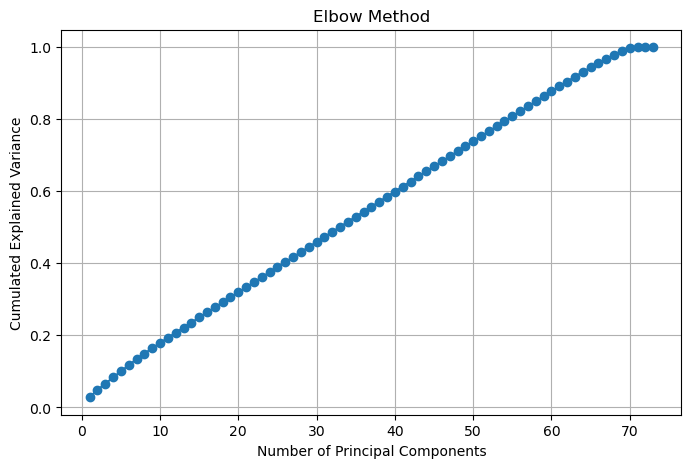

Optimal number of PC = 66


In [49]:
pca = PCA()
pca.fit(X_train_scaled)

ratio_cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize = (8,5))
plt.plot(range(1, len(ratio_cumulative_variance) + 1), ratio_cumulative_variance, marker = 'o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulated Explained Variance")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

n_components_optimal = 1 + np.argmax(ratio_cumulative_variance >= 0.95)
print(f"Optimal number of PC = {n_components_optimal}")

<br>

&nbsp;&nbsp;&nbsp;Now that we know the number of Principal Components (66), we can apply the PCA with it. Finally having the results of this unsupervised model makes us henceforth able to create the variables *X_pca* and *X_test_pca*, respectively based on *X_train_scaled* and *X_test_scaled*. We can also fit and evaluate the models just as before.

In [50]:
pca = PCA(n_components = n_components_optimal)
X_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

for name, model in models_scaling.items():
    model.fit(X_pca, y_train)
    model_evaluation_imbalance(model, X_test_pca, y_test, f"PCA for {name}")


---- PCA for Logistic Regression Model ----
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     27446
           1       0.41      0.86      0.55      2550

    accuracy                           0.88     29996
   macro avg       0.70      0.87      0.74     29996
weighted avg       0.94      0.88      0.90     29996


Confusion Matrix:
[[24238  3208]
 [  355  2195]]

AUC-PR = 0.79, AUC-ROC = 0.96

Custom Cost = 6758



---- PCA for SVC Model ----
              precision    recall  f1-score   support

           0       0.98      0.89      0.94     27446
           1       0.42      0.85      0.56      2550

    accuracy                           0.89     29996
   macro avg       0.70      0.87      0.75     29996
weighted avg       0.94      0.89      0.90     29996


Confusion Matrix:
[[24438  3008]
 [  384  2166]]

AUC-PR = 0.76, AUC-ROC = 0.95

Custom Cost = 6848



---- PCA for KNN Model ----
              precision    recall  f1

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;One can remark that the PCA gave us results similar to the ones with the StandardScaler only. Therefore, from all the non-scaled models tested, the XGB and Gradient from the baseline are the best ones, while the LogisticRegression is the best scaled model (without the PCA). Those are the three models that will be tested with GridSearch to find the best hyperparameters for each of those models.

<br><br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**D. GridSearch and management of the overfitting**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this fourth subpart, we will apply three different GridSearch to find the best hyperparameters of the LogisticRegression, the XGBoost and the GradientBoosting without them overfitting too much. Performing these GridSearch will also help cope with the overfitting, especially by using cross-validation. <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;For each GridSearch, we will first define the hyperparameters that we want to test, then call the *GridSearchCV* itself on the corresponding model and hyperparameters with a metric (scoring) to improve (in general, *recall_macro*). In all our models, we will take 2 folds (*cv = 2*) to reduce the compilation time as the GridSearch is very costly, but still have iterations to try all the combinations of all the different subsamples. To specify that we do not want to train again the final model (the one selected by the Grid), to store the best estimator while keeping the CV score, we added the parameter *refit = False* in the GridSearch to gain some time. It will be done later and we will display its result using the *model_evaluation_imbalance* method. 

<br>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**a. GridSearch on GradientBoosting**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Let us begin with the GradientBoosting. We indicated that the goal was to minimize the loss (whether it was the exponential loss or the log-loss). It will definitely decide on which one of the stable models (with log-loss) or the more aggressive (using exponential loss) is the best one. Several learning rates (between 0.01 and 0.04) have been tested to allow the model to learn from the training dataset but without overfitting too much (having a learning rate too high ($\geq$ 0.5)). <br>About the *min_samples_split* and *min_samples_leaf* hyperparameters, we respectively allowed values between 20 and 50 and between 10 and 20 to ensure that the model does not focus too much on the details, but enough to make new splits or new leafs for the more recurrent patterns. <br>To lower the variance and to have a good regularization, maximal depths between 3 and 6 have been used. <br>For the maximum features, we chose the square root, a choice commonly used to lower the correlation between the different trees from the gradient. <br>Moreover, different subsamples such as 0.5, 0.8, 0.85 or 0.618 (the golden ratio, equal to $\frac{1 + \sqrt{5}}{2}$) have been used to drop the variance and therefore avoid overfitting. <br>Finally, 10 estimators have been chosen to reduce the compilation time.

In [51]:
parameters = { "loss": ["exponential", "log_loss"], "learning_rate": [0.01, 0.025, 0.03, 0.04], "min_samples_split": [20, 30, 40, 50], 
              "min_samples_leaf": [10, 15, 20], "max_depth": [3, 5, 6], "max_features": ["log2", "sqrt"],
            "criterion": ["friedman_mse", "squared_error"], "subsample": [0.5, 0.618, 0.8, 0.85], "n_estimators": [10] }

clf_gradient = GridSearchCV(GradientBoostingClassifier(), parameters, scoring = "recall_macro", refit = False, cv = 2, n_jobs = -1, verbose = 3)
clf_gradient.fit(X_train, y_train)

print(f"\nBest parameters (GradientBoosting): {clf_gradient.best_params_}\nBest CV ROC AUC: {clf_gradient.best_score_}")

best_gradient = GradientBoostingClassifier(**clf_gradient.best_params_)
best_gradient.fit(X_train, y_train)

model_evaluation_imbalance(best_gradient, X_test, y_test, "GradientBoosting")

Fitting 2 folds for each of 4608 candidates, totalling 9216 fits

Best parameters (GradientBoosting): {'criterion': 'friedman_mse', 'learning_rate': 0.04, 'loss': 'log_loss', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 50, 'n_estimators': 10, 'subsample': 0.8}
Best CV ROC AUC: 0.5115126050420168

---- GradientBoosting Model ----
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     27446
           1       1.00      0.00      0.01      2550

    accuracy                           0.92     29996
   macro avg       0.96      0.50      0.48     29996
weighted avg       0.92      0.92      0.88     29996


Confusion Matrix:
[[27446     0]
 [ 2540    10]]

AUC-PR = 0.81, AUC-ROC = 0.94

Custom Cost = 25400




&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;This first gradient can't be used due to the catastrophic results for the minority class, leading to a huge CC (it overfits too much) despite our precautions. It is probably caused by the handling of the imbalance of the target. Therefore, we decided to try another GridSearch with a greater number of parameters (hundreds instead of 10), with more *min_samples_split* in the parameters grid and with a balanced weight. However, whatever the model was, the GridSearch always gave us catastrophic results for the minority class.

<br><br>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**b. GridSearch on XGBoost**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Let us now continue with the GridSearch on the XGBoost model. <br>
For the maximal depth, we used this time "low" depths ($\in [|3, 8|]$) just as before, but also higher ones to allow the XGB to express more, even if it accentuates the risk of overfitting. Because we saw the devastating consequences of a learning rate greater than 0.4 on our dataset, we only selected learning rates below this threshold.<br>
About the $\gamma$ hyperparameter, we chose one equal to 0 to allow the model to be more flexible, but also strictly positive ones to prevent overfitting. <br>
For the number of estimators, we also understood the importance of having hundreds of estimators. This is why we henceforth decided to take at least 100 estimators, but also 500 and 1000 to see what it gets (but taking the risk of overfitting).<br>Finally, 90% of the training dataset has been used for training the model (*subsample = 0.9*), and 50% of features were used for each tree (*colsample_bytree = 0.5*) to decrease the correlation between the different trees and introduce randomness. 

In [52]:
params_xgb = {'max_depth': [3, 4, 5, 6, 8, 10, 12, 15], 'learning_rate': [0.001, 0.01, 0.1, 0.20, 0.25, 0.30], "gamma":[0, 0.25, 0.5, 0.75,1], 
              'n_estimators': [100, 500, 1000], "subsample":[0.9], "colsample_bytree":[0.5]}

clf_xgb = GridSearchCV(XGBClassifier(), params_xgb, scoring = "recall_macro", refit = False, cv = 2, n_jobs = -1, verbose = 1)
clf_xgb.fit(X_train, y_train)

print(f"\nBest parameters (XGBoost): {clf_xgb.best_params_}\nBest CV ROC AUC: {clf_xgb.best_score_}")

best_xgb = XGBClassifier(**clf_xgb.best_params_)
best_xgb.fit(X_train, y_train)

model_evaluation_imbalance(best_xgb, X_test, y_test, "XGBoost")

Fitting 2 folds for each of 720 candidates, totalling 1440 fits

Best parameters (XGBoost): {'colsample_bytree': 0.5, 'gamma': 0, 'learning_rate': 0.3, 'max_depth': 4, 'n_estimators': 1000, 'subsample': 0.9}
Best CV ROC AUC: 0.853097804410031

---- XGBoost Model ----
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     27446
           1       0.88      0.70      0.78      2550

    accuracy                           0.97     29996
   macro avg       0.93      0.85      0.88     29996
weighted avg       0.96      0.97      0.96     29996


Confusion Matrix:
[[27196   250]
 [  753  1797]]

AUC-PR = 0.86, AUC-ROC = 0.97

Custom Cost = 7780




&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;This model is the best one that we have ever had for the moment. Indeed, if we consider every parameter, it has one of the lowest Custom Cost (7780), the biggest recall (0.7), and excellent scores for the AUC-ROC and AUC-PR (0.86 and 0.97). Compared to the Gradient GridSearch, it does not favor the majoritarian class too much.  

<br><br>

### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**c. GridSearch on LogisticRegression**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Finally, let us perform the GridSearch on the LogisticRegression. To make sure to test the more parameters possible without having incompatible hyperparameters (and therefore warnings), we split the *params_log* into several parts. <br>
For the penalties, we tried the *L1*, *L2*, and *ElasticNet* to have a stable model avoiding extreme weights. The case where the penalty is None was also treated even if in general, it is not used, because sometimes using a model without penalties is enough to be the best model.<br>
About the regularization strength C, we used a logspace to compensate for variance and the bias. For the several hyperparameters: "big" ones (with $10^4$ values) to make the model regularize more, and "smaller" ones to increase the reconnaissance of patterns inside the diabetic class. All the solvers were used in adequation to these penalties.<br>
Finally, to ensure the convergence of the model, several number of iterations were chosen, from 100 to 5000.

In [53]:
params_log = [{"penalty": ["l2", None], "C": np.logspace(-4, 4, 20), "solver": ["lbfgs", "newton-cg", "sag"], "max_iter": [100, 1000, 2500, 5000]},
              {"solver": ["liblinear"], "penalty": ["l1", "l2"], "C": np.logspace(-4, 4, 20), "max_iter": [100, 1000, 2500, 5000]},
              {"solver": ["saga"], "penalty": ["l1", "l2", "elasticnet", None], "C": np.logspace(-4, 4, 20), "l1_ratio": [0.0, 0.5, 1.0], 
               "max_iter": [100, 1000, 2500, 5000]}]

clf_log = GridSearchCV(LogisticRegression(), params_log, scoring = "recall_macro", refit = False, cv = 2, n_jobs = -1, verbose = 3)
clf_log.fit(X_train_scaled, y_train)

print(f"\nBest parameters (LogisticRegression): {clf_log.best_params_}\nBest CV ROC AUC: {clf_log.best_score_}")

best_log = LogisticRegression(**clf_log.best_params_)
best_log.fit(X_train_scaled, y_train)

model_evaluation_imbalance(best_log, X_test_scaled, y_test, "LogisticRegression")

Fitting 2 folds for each of 1600 candidates, totalling 3200 fits

Best parameters (LogisticRegression): {'C': np.float64(4.281332398719396), 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV ROC AUC: 0.8100313004512865

---- LogisticRegression Model ----
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     27446
           1       0.86      0.63      0.73      2550

    accuracy                           0.96     29996
   macro avg       0.91      0.81      0.85     29996
weighted avg       0.96      0.96      0.96     29996


Confusion Matrix:
[[27190   256]
 [  942  1608]]

AUC-PR = 0.81, AUC-ROC = 0.96

Custom Cost = 9676




&nbsp;&nbsp;&nbsp;This model presents some good metrics (for instance, an AUC-ROC of 0.96, and a precision of 0.86 for the minority class). However, the XGBoost model with GridSearch has a Custom Cost which is really better than the LogisticRegression one (7780 against 9676), which makes it the best model from the GridSearch. From all the models that were tested since the beginning of the project, this XGBoost is in the top 3 with the XGB and Gradient from the baseline. Therefore, they are the three ones that will be tested in the Voting, Stacking, and Bagging.

<br><br>

## &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**E. Voting, Bagging & Stacking**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;From what we said before, the best three models from this notebook are the XGB and Gradient from the baseline, but also the XGB with GridSearch. Therefore, the first step will be to define them once again. Then, ensemble techniques such as Voting, Bagging, and Stacking will be applied to them to have the best metrics for these specified models. While Voting improves the robustness by introducing diversity, the Bagging aims to avoid overfitting, and reduce the model's variance. Finally, the Stacking has for purpose to maximize the predictive power.<br>

In [55]:
# Best models
XGB_grid = XGBClassifier(colsample_bytree = 0.5, gamma = 0, learning_rate = 0.3, max_depth = 4, n_estimators = 1000, subsample = 0.9, random_state = 42,
    eval_metric = "logloss")

XGB_baseline = XGBClassifier(random_state = 42, eval_metric = "logloss", learning_rate = 0.1, max_depth = 5)
Gradient_baseline = GradientBoostingClassifier(random_state = 42, n_estimators = 300, learning_rate = 0.05, max_depth = 3, min_samples_split = 20, 
                                               min_samples_leaf = 10)


# Voting
voting = VotingClassifier(estimators = [('xgb_grid', XGB_grid), ('xgb_baseline', XGB_baseline), ('gradient_base', Gradient_baseline)], voting = 'soft',
                          n_jobs = -1)

voting.fit(X_train, y_train)
model_evaluation_imbalance(voting, X_test, y_test, "Voting")


# Bagging
bagging = BaggingClassifier(estimator = XGB_grid, random_state = 42, n_estimators = 10, max_samples = 0.8, max_features = 1.0, n_jobs = -1, 
                            bootstrap = True)
bagging.fit(X_train, y_train)
model_evaluation_imbalance(bagging, X_test, y_test, "Bagging")


# Stacking
stacking = StackingClassifier(estimators = [('xgb_grid', XGB_grid), ('xgb_baseline', XGB_baseline), ('gradient_base', Gradient_baseline)],
            final_estimator = LogisticRegression(max_iter = 500, solver = "liblinear"), stack_method = "predict_proba", n_jobs = -1, passthrough = False)
stacking.fit(X_train, y_train)
model_evaluation_imbalance(stacking, X_test, y_test, "Stacking")


---- Voting Model ----
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27446
           1       0.97      0.69      0.80      2550

    accuracy                           0.97     29996
   macro avg       0.97      0.84      0.89     29996
weighted avg       0.97      0.97      0.97     29996


Confusion Matrix:
[[27383    63]
 [  798  1752]]

AUC-PR = 0.88, AUC-ROC = 0.98

Custom Cost = 8043



---- Bagging Model ----
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     27446
           1       0.92      0.69      0.79      2550

    accuracy                           0.97     29996
   macro avg       0.95      0.84      0.89     29996
weighted avg       0.97      0.97      0.97     29996


Confusion Matrix:
[[27296   150]
 [  784  1766]]

AUC-PR = 0.86, AUC-ROC = 0.97

Custom Cost = 7990



---- Stacking Model ----
              precision    recall  f1-score   support

          

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Now, one can remark that, if we first focus on the three ensembles, the Stacking has the best recall from the three (0.71), the least FN (739) and the least Custom Cost (7561). Despite the fact that he predicted more FP (171) than the others, it is still acceptable, as it also has the biggest AUC-ROC and AUC-PR of the three (0.97 and 0.88).<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;We can also say that it is the best model that we had in this notebook because it has a better recall than the XGBoost from Grid Search (0.71 v 0.7), less FP and FN (739 against 753 for the FN and 171 against 250 for the FP). Finally, the CC of the Stacking is equal to 7561, which is one of the lowest.<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;To know exactly which model composed the Stacking (with the best scores ever), we will apply another GridSearch, but on the Stacking itself.

In [56]:
base_estimators = [('Grad_baseline', Gradient_baseline), ('xgb_base', XGB_baseline), ('xgb_grid', XGB_grid)]
stack = StackingClassifier(estimators = base_estimators, final_estimator = LogisticRegression(), stack_method = "predict_proba", n_jobs = -1)

parameters = {'final_estimator': [LogisticRegression(max_iter = 500, solver = "liblinear"), RandomForestClassifier(n_estimators = 200, random_state = 42),
        GradientBoostingClassifier(random_state = 42)], 'passthrough': [False, True]}

grid_stacking = GridSearchCV(estimator = stack, param_grid = parameters, scoring = "recall_macro", cv = 3, n_jobs = -1, verbose = 3)
grid_stacking.fit(X_train, y_train)
print(f"Best stacking: {grid_stacking.best_estimator_} with paramaters: {grid_stacking.best_params_}")
model_evaluation_imbalance(grid_stacking.best_estimator_, X_test, y_test, "Best Stacking")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best stacking: StackingClassifier(estimators=[('Grad_baseline',
                                GradientBoostingClassifier(learning_rate=0.05,
                                                           min_samples_leaf=10,
                                                           min_samples_split=20,
                                                           n_estimators=300,
                                                           random_state=42)),
                               ('xgb_base',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                               

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;From what we understand, the best model ever is the: GradientBoosting with: *learning_rate* = 0.05, *min_samples_leaf* = 10, *min_samples_split* = 20, *n_estimators* = 300, *random_state* = 42. We will now use this best model to create another column called *predicted_diabetes* with the final results on the initial dataset. To see what the results look like, we will also upload the CSV file called `diabetes_dataset_with_predictions.csv`.

In [57]:
best_stacking = GradientBoostingClassifier(learning_rate = 0.05, min_samples_leaf = 10, min_samples_split = 20, n_estimators = 300, random_state = 42)
best_stacking.fit(X_train, y_train)
data["predicted_diabetes"] = best_stacking.predict(X)
data.to_csv("diabetes_dataset_with_predictions.csv", index = False)

<br><br><br>

# **Conclusion:**

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this project, we tried to create the most efficient, performant, and reliable model to help detect early diabetes using the patient's personal and medical information. Through detailed exploratory data analysis, data cleaning, encoding, and handling missing or inconsistent values, we ensured the dataset was prepared for modeling. To evaluate the models every time they were tested, we used the classification report (with accuracy, $F_1$ score, recall, and precision for both classes of the target) and the confusion matrix. Another metric that we created was the Custom Cost to give a weight of 10 to every False Negative of the corresponding model's prediction, and a weight of 1 to every False Negative. Even if it was determinant in the choice of the best model (the goal was to prevent as much as possible the worst prediction case (FN) and the second worst (FP)), the metric results had to follow for the model to be the one chosen. <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;A major challenge that we faced in this dataset was the target's strong class imbalance (ratio of 1:10.76), with far fewer diabetic patients than non-diabetic ones. Even if we tried several techniques such as SMOTE, RandomUnderSampling, and RandomOversampling to ensure fair learning, it did not improve the results. Scaling the data and applying the PCA did not have the best results either. Therefore, we decided to apply the GridSearch on the best 3 models until then: the XGBoost and GradientBoosting from the baseline for the non-scaled models, but also the LogisticRegression after scaling the data (but without the PCA). <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;While the Grid Search improved the results for the XGBoost, despite all the handling of overfitting with hyperparameter tuning and cross-validation, it kept overfitting too much for the GradientBoosting. Therefore, we decided to use the XGBoost through the Voting, Bagging, and Stacking. After finding out that the best model from all tested was the Gradient Boosting from the Stacking, we were able to apply it one last time, but this time on the original dataset, *df* and not on the encoded one, *df_encoded*. This allowed us to create a new feature called *predicted_diabetes* with the results predicted by this model. To be able to have a direct comparison by just looking at the dataset, we put *predicted_diabetes* just next to the true results (feature "diabetes"). <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Even if we still have false predictions in the final model, we still got an accuracy of 97% in the model. Let us try to compare these results to the tests currently used in the United States of America (because this dataset is about American patients, as we saw during the study of *Location* feature) to detect the hbA1c. Indeed, there is no test for diabetes itself. Despite the fact that we do not have specific results on the reliability of those tests, the website Niddk of the American Health Ministry published in July 2022 an article (which link is: [https://www.niddk.nih.gov/health-information/diabetes/overview/tests-diagnos](https://)) explaining that this test was sensible at 40% - 60%, while it was specific in 80% - 90% of cases. Because of the great results that we had and the lack of direct tests to detect diabetes, we are ready to propose this solution to help reduce healthcare costs and the early detection to prevent severe complications in the United States diabetes.